## CREDENCE — Credit Risk Edge: Analytics, Intelligence
## Análise de Risco de Crédito | Lending Club Loan Data (2007–2018)

**Tese central:** O grade é um proxy imperfeito de risco. O principal padrão observado de default não está no grade isoladamente,
mas na combinação de term longo + DTI elevado + purpose de alto risco.
Dentro do Grade C, essa combinação pode atingir default rate comparável ao Grade F.

**Conclusão executiva:** A inadimplência não subiu por um único fator isolado. A combinação entre piora do mix de risco, prazo de 60 meses, DTI elevado e segmentos intermediários mal precificados aparece como principal vetor observado. Grades D/E têm risco estruturalmente maior, mas a maior oportunidade de gestão não está apenas em cortar os piores grades; está em reprecificar ou restringir combinações específicas com P&L negativo.

---

## Seção 1 — Contexto e Setup

### Por que filtramos `loan_status`?

O dataset contém empréstimos com desfecho desconhecido (`Current`, `In Grace Period`, `Late`).
Incluí-los na análise contaminaria a taxa base de inadimplência — estamos observando um snapshot
de contratos ainda em andamento, não seu resultado final.

**Regra de classificação:**
- `default_flag = 1` → Charged Off, Default (e variantes "Does not meet credit policy")
- `default_flag = 0` → Fully Paid (e variantes)
- **Excluídos:** Current, In Grace Period, Late (16–30d), Late (31–120d), Issued

---

> **Versão avançada.** Este notebook estende a análise canônica com quatro técnicas de risco de
> crédito de nível comitê: **(1)** análise de sobrevivência (Kaplan-Meier + Cox) — Seção 6;
> **(2)** calibração probabilística — Seção 5.5; **(3)** validação temporal treino/teste — Seção 5.4;
> **(4)** interpretação econômica via efeitos marginais e elasticidade — Seção 5.6.
> As Seções 7–9 correspondem às antigas 6–8 do notebook canônico.

>
> **Principais achados desta versão.** *(1)* O modelo de risco mantém o poder de **ordenação**
> fora do tempo (AUC 0,71 → 0,68 de 2007–2015 para 2016–2018), mas **subestima o default
> observado em 3–7 p.p.** nas safras recentes — recalibrar é obrigatório antes de usar as
> probabilidades em provisão ou pricing. *(2)* Os efeitos marginais confirmam **term e DTI como
> as alavancas acionáveis** do underwriting: prazo de 60 meses adiciona +6,7 p.p. de
> probabilidade de default e cada 10 p.p. de DTI, +1,7 p.p. *(3)* A análise de sobrevivência
> confirma que 60 meses **acelera** o default (log-rank χ² ≈ 25.000, p < 0,001; Cox HR > 1);
> a leitura de vintage é confiável para safras maduras (≤ 2015) e a deterioração de 2014–2015
> reaparece de forma independente.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency, norm
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import missingno as msno
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.duration.hazard_regression import PHReg
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

SEED = 42
np.random.seed(SEED)
print('✓ Imports OK')


✓ Imports OK


In [2]:
# ── Carregar dados ──────────────────────────────────────────
COLS = [
    'loan_amnt', 'int_rate', 'grade', 'sub_grade', 'annual_inc', 'dti',
    'purpose', 'term', 'home_ownership', 'emp_length', 'verification_status',
    'issue_d', 'loan_status', 'installment', 'addr_state', 'revol_util', 'total_acc', 'last_pymnt_d'
]

df_raw = pd.read_csv('../data/raw/loan.csv', usecols=COLS, low_memory=False)
print(f'Dataset bruto: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')

# ── Filtrar target ───────────────────────────────────────────
STATUS_PAID    = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']
STATUS_DEFAULT = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']

mask = df_raw['loan_status'].isin(STATUS_PAID + STATUS_DEFAULT)
df = df_raw[mask].copy()
print(f'Dataset modelável: {len(df):,} linhas  ({len(df)/len(df_raw)*100:.1f}% do total)')
print(f'Excluídos (desfecho desconhecido): {(~mask).sum():,} registros')

# ── default_flag ─────────────────────────────────────────────
df['default_flag'] = df['loan_status'].isin(STATUS_DEFAULT).astype(int)
print(f"\nDefault rate base: {df['default_flag'].mean()*100:.1f}%")
print(df['default_flag'].value_counts().rename({0:'Fully Paid', 1:'Charged Off/Default'}))


Dataset bruto: 2,260,668 linhas × 18 colunas
Dataset modelável: 1,306,387 linhas  (57.8% do total)
Excluídos (desfecho desconhecido): 954,281 registros

Default rate base: 20.1%
default_flag
Fully Paid             1043940
Charged Off/Default     262447
Name: count, dtype: int64


In [3]:
# ── Tratamentos padrão ──────────────────────────────────────

# int_rate: garantir float (algumas versões do dataset vêm com %)
df['int_rate'] = pd.to_numeric(
    df['int_rate'].astype(str).str.replace('%', '').str.strip(), errors='coerce'
)

# term: " 36 months" → 36
df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')

# emp_length: "10+ years" → 10, "< 1 year" → 0
def parse_emp_length(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    if val == '10+ years': return 10
    if val == '< 1 year':  return 0
    digits = ''.join(filter(str.isdigit, val))
    return int(digits) if digits else np.nan

df['emp_length'] = df['emp_length'].apply(parse_emp_length)

# issue_d: "Dec-2018" → datetime → ano e mês
df['issue_d']     = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year']  = df['issue_d'].dt.year.astype('Int64')
df['issue_month'] = df['issue_d'].dt.month.astype('Int64')

# last_pymnt_d: eixo do tempo da analise de sobrevivencia (Secao 6)
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y', errors='coerce')

# annual_inc: winsorizar p99 (outliers até $5M distorcem visualizações)
P99_INC = df['annual_inc'].quantile(0.99)
df['annual_inc_w'] = df['annual_inc'].clip(upper=P99_INC)

print(f'Tratamentos aplicados.')
print(f'annual_inc winsorizado no p99 = ${P99_INC:,.0f}')
print(f'\nShape final: {df.shape}')
print(f'Período: {df["issue_year"].min()} – {df["issue_year"].max()}')


Tratamentos aplicados.
annual_inc winsorizado no p99 = $250,000

Shape final: (1306387, 22)
Período: 2007 – 2018


In [4]:
# ── Visão geral de missing values (colunas-chave) ───────────
missing = df[COLS].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_n'] > 0]
print('=== Missing values (apenas colunas com nulos) ===')
print(missing_df)


=== Missing values (apenas colunas com nulos) ===
              missing_n  missing_%
emp_length        75491       5.78
last_pymnt_d       2273       0.17
revol_util          850       0.07
dti                 312       0.02
total_acc            29       0.00
annual_inc            4       0.00


---
## Seção 2 — Análise Exploratória (EDA)

Antes de qualquer modelagem, precisamos entender as distribuições e identificar padrões visuais.
A EDA responde três perguntas:
1. **Quem** toma empréstimos? (perfil socioeconômico)
2. **Por quê** tomam? (purpose e term)
3. **Quem não paga?** (default rate por segmento)


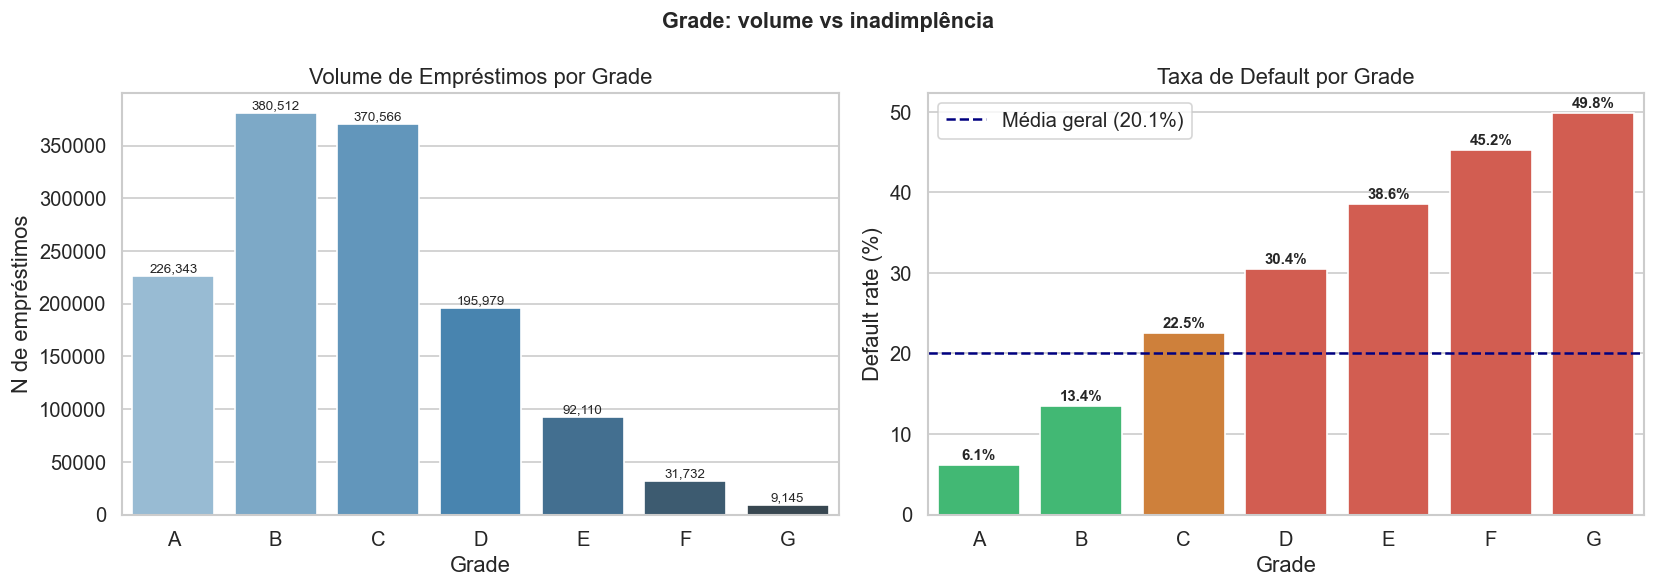

grade  n_loans  default_rate_pct
    A   226343          6.086338
    B   380512         13.447145
    C   370566         22.511240
    D   195979         30.434894
    E    92110         38.569102
    F    31732         45.247699
    G     9145         49.797704


In [5]:
# ── 2.1 Default rate por Grade ──────────────────────────────
grade_stats = (
    df.groupby('grade')
    .agg(n_loans=('default_flag','count'), default_rate=('default_flag','mean'))
    .reset_index()
)
grade_stats['default_rate_pct'] = grade_stats['default_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume por grade
sns.barplot(data=grade_stats, x='grade', y='n_loans', palette='Blues_d', ax=axes[0])
axes[0].set_title('Volume de Empréstimos por Grade')
axes[0].set_ylabel('N de empréstimos')
axes[0].set_xlabel('Grade')
for bar, n in zip(axes[0].patches, grade_stats['n_loans']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{n:,}', ha='center', va='bottom', fontsize=8)

# Default rate por grade
colors = ['#2ecc71' if r < 15 else '#e67e22' if r < 30 else '#e74c3c'
          for r in grade_stats['default_rate_pct']]
sns.barplot(data=grade_stats, x='grade', y='default_rate_pct', palette=colors, ax=axes[1])
axes[1].axhline(df['default_flag'].mean()*100, color='navy', linestyle='--', linewidth=1.5,
                label=f'Média geral ({df["default_flag"].mean()*100:.1f}%)')
axes[1].set_title('Taxa de Default por Grade')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Grade')
axes[1].legend()
for bar, rate in zip(axes[1].patches, grade_stats['default_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Grade: volume vs inadimplência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/01_grade_default.png', bbox_inches='tight')
plt.show()
print(grade_stats[['grade','n_loans','default_rate_pct']].to_string(index=False))


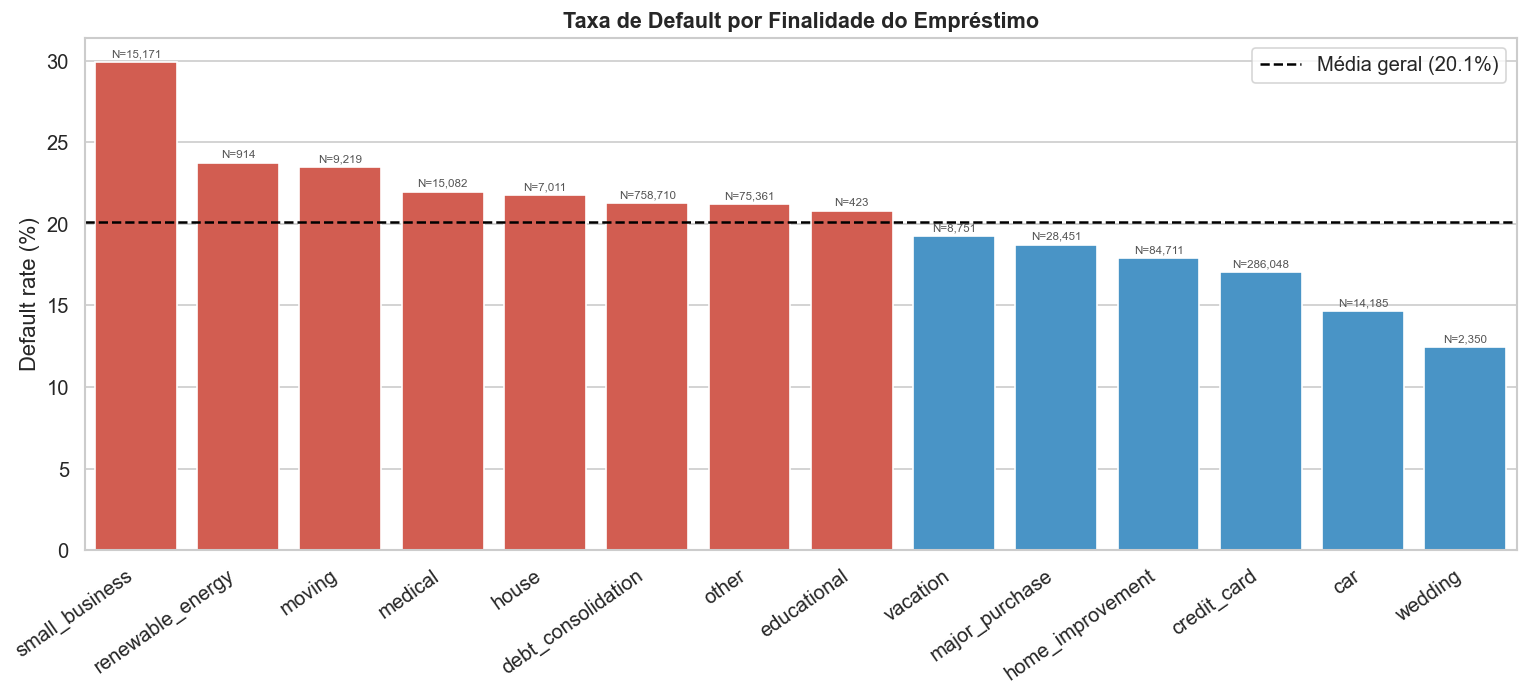

In [6]:
# ── 2.2 Default rate por Purpose ────────────────────────────
purpose_stats = (
    df.groupby('purpose')
    .agg(n_loans=('default_flag','count'), default_rate=('default_flag','mean'))
    .reset_index()
    .sort_values('default_rate', ascending=False)
)
purpose_stats['default_rate_pct'] = purpose_stats['default_rate'] * 100
avg_rate = df['default_flag'].mean() * 100

fig, ax = plt.subplots(figsize=(13, 6))
bars = sns.barplot(data=purpose_stats, x='purpose', y='default_rate_pct',
                   palette=['#e74c3c' if r > avg_rate else '#3498db'
                            for r in purpose_stats['default_rate_pct']], ax=ax)
ax.axhline(avg_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Média geral ({avg_rate:.1f}%)')
ax.set_title('Taxa de Default por Finalidade do Empréstimo', fontsize=13, fontweight='bold')
ax.set_ylabel('Default rate (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend()

for bar, row in zip(ax.patches, purpose_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'N={row.n_loans:,}', ha='center', va='bottom', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('../assets/02_purpose_default.png', bbox_inches='tight')
plt.show()


Term × Default rate:
 term  n_loans  default_rate  default_rate_pct
   36   991212      0.161235         16.123493
   60   315175      0.325625         32.562545


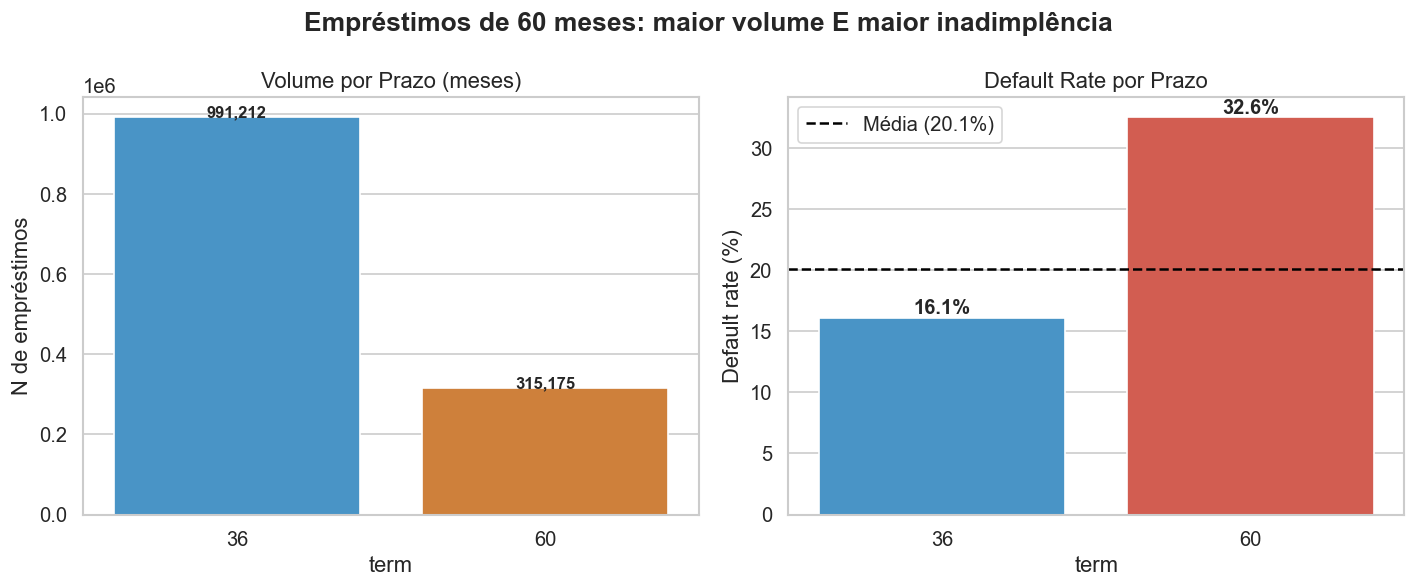

In [7]:
# ── 2.3 Term: 36 vs 60 meses ────────────────────────────────
term_stats = (
    df.groupby('term')
    .agg(n_loans=('default_flag','count'), default_rate=('default_flag','mean'))
    .reset_index()
)
term_stats['default_rate_pct'] = term_stats['default_rate'] * 100
print('Term × Default rate:')
print(term_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=term_stats, x='term', y='n_loans',
            palette=['#3498db','#e67e22'], ax=axes[0])
axes[0].set_title('Volume por Prazo (meses)')
axes[0].set_ylabel('N de empréstimos')
for bar, n in zip(axes[0].patches, term_stats['n_loans']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{n:,}', ha='center', fontsize=10, fontweight='bold')

sns.barplot(data=term_stats, x='term', y='default_rate_pct',
            palette=['#3498db','#e74c3c'], ax=axes[1])
axes[1].axhline(avg_rate, color='black', linestyle='--', label=f'Média ({avg_rate:.1f}%)')
axes[1].set_title('Default Rate por Prazo')
axes[1].set_ylabel('Default rate (%)')
axes[1].legend()
for bar, rate in zip(axes[1].patches, term_stats['default_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Empréstimos de 60 meses: maior volume E maior inadimplência', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/03_term_default.png', bbox_inches='tight')
plt.show()


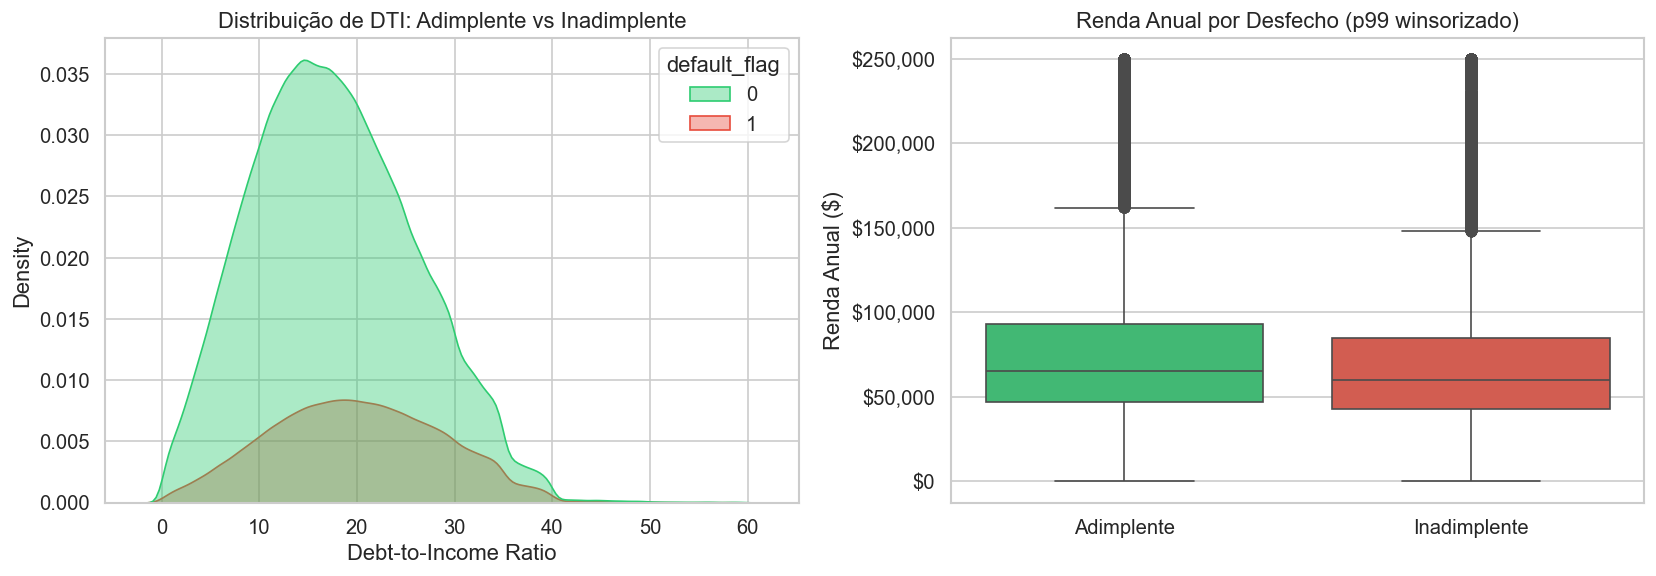

Renda mediana por desfecho:
default_flag
Adimplente      65000.0
Inadimplente    60000.0
Name: annual_inc, dtype: float64

DTI mediano por desfecho:
default_flag
Adimplente      17.09
Inadimplente    19.76
Name: dti, dtype: float64


In [8]:
# ── 2.4 Perfil socioeconômico: DTI e Annual Income ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DTI por default_flag
dti_capped = df[df['dti'] <= 60].copy()
sns.kdeplot(data=dti_capped, x='dti', hue='default_flag',
            palette={0:'#2ecc71', 1:'#e74c3c'}, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Distribuição de DTI: Adimplente vs Inadimplente')
axes[0].set_xlabel('Debt-to-Income Ratio')

# Annual income (winsorizado) por default_flag
sns.boxplot(data=df, x='default_flag', y='annual_inc_w', hue='default_flag',
            palette={0:'#2ecc71', 1:'#e74c3c'}, legend=False, ax=axes[1])
axes[1].set_title('Renda Anual por Desfecho (p99 winsorizado)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Adimplente', 'Inadimplente'])
axes[1].set_ylabel('Renda Anual ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../assets/04_socioeconomico.png', bbox_inches='tight')
plt.show()

print('Renda mediana por desfecho:')
print(df.groupby('default_flag')['annual_inc'].median().rename({0:'Adimplente', 1:'Inadimplente'}))
print('\nDTI mediano por desfecho:')
print(df.groupby('default_flag')['dti'].median().rename({0:'Adimplente', 1:'Inadimplente'}))


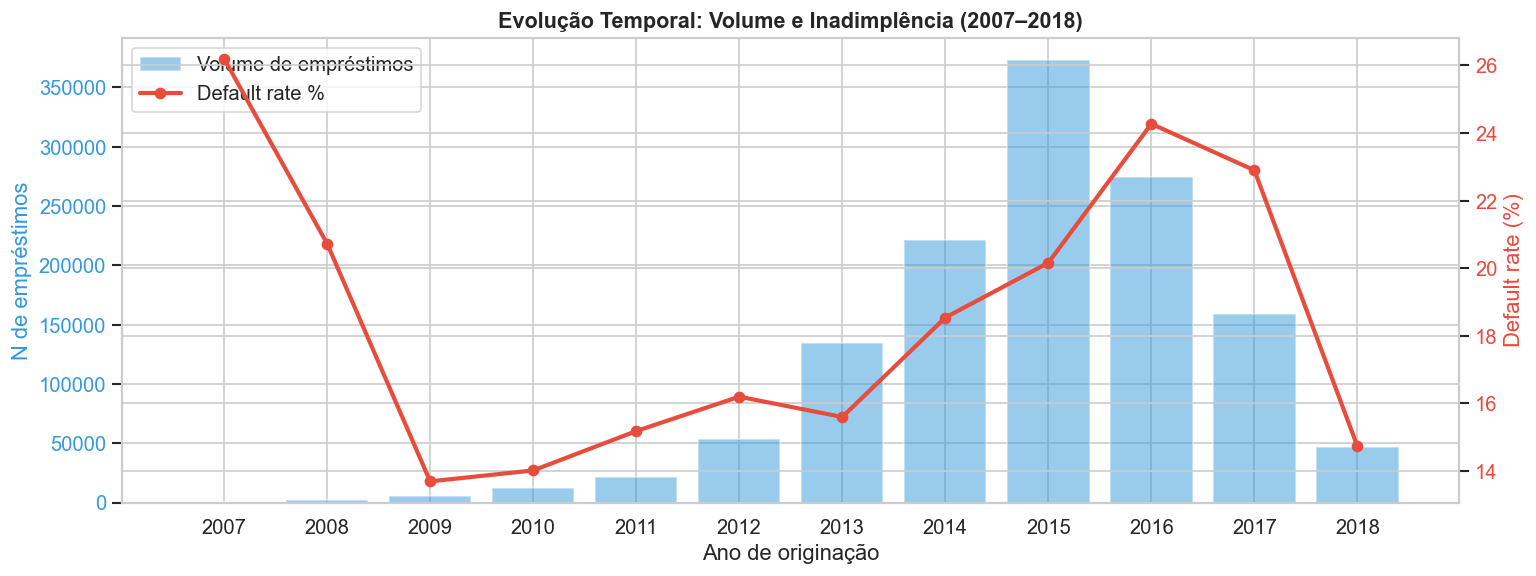

 issue_year  n_loans  default_rate_pct
       2007      603         26.202322
       2008     2393         20.727121
       2009     5281         13.690589
       2010    12537         14.014517
       2011    21721         15.178859
       2012    53367         16.197275
       2013   134793         15.595765
       2014   221468         18.538118
       2015   373412         20.158699
       2016   274711         24.272417
       2017   158910         22.899125
       2018    47191         14.729504


In [9]:
# ── 2.5 Evolução temporal da inadimplência ──────────────────
temporal = (
    df.groupby('issue_year')
    .agg(n_loans=('default_flag','count'), default_rate=('default_flag','mean'))
    .reset_index()
    .dropna(subset=['issue_year'])
)
temporal['default_rate_pct'] = temporal['default_rate'] * 100

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

bars = ax1.bar(temporal['issue_year'], temporal['n_loans'],
               color='#3498db', alpha=0.5, label='Volume de empréstimos')
ax1.set_ylabel('N de empréstimos', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

line = ax2.plot(temporal['issue_year'], temporal['default_rate_pct'],
                color='#e74c3c', marker='o', linewidth=2.5, label='Default rate %')
ax2.set_ylabel('Default rate (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Evolução Temporal: Volume e Inadimplência (2007–2018)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Ano de originação')
ax1.set_xticks(temporal['issue_year'].dropna().astype(int))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../assets/05_temporal.png', bbox_inches='tight')
plt.show()
print(temporal[['issue_year','n_loans','default_rate_pct']].to_string(index=False))


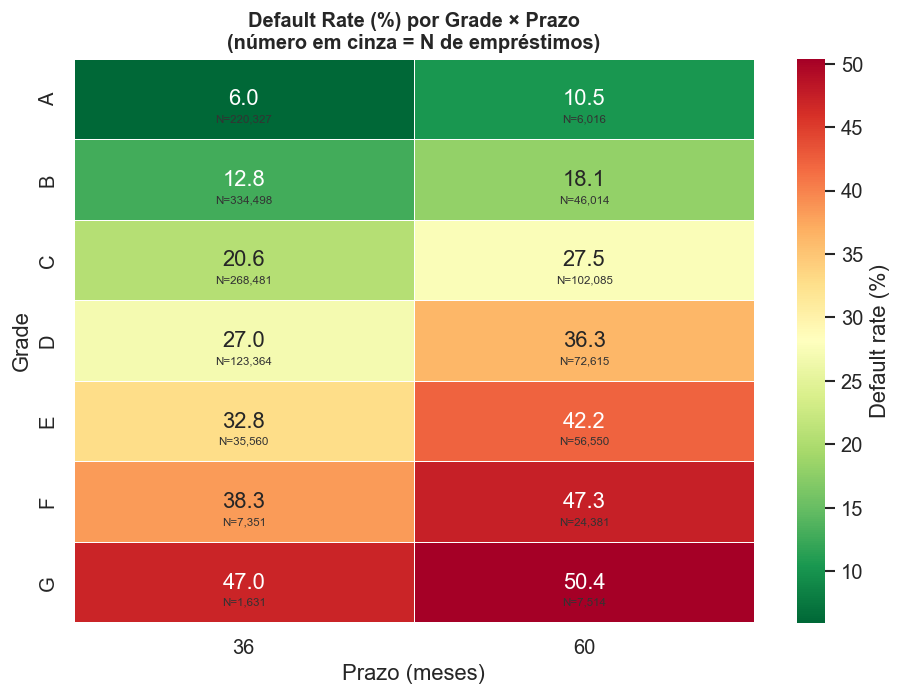

In [10]:
# ── 2.6 Heatmap: Grade × Term (default rate) ────────────────
heat = df.groupby(['grade','term'])['default_flag'].agg(['mean','count']).reset_index()
heat.columns = ['grade','term','default_rate','n']
heat_pivot = heat.pivot(index='grade', columns='term', values='default_rate') * 100
n_pivot    = heat.pivot(index='grade', columns='term', values='n')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heat_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Default rate (%)'})

# Anotar N
for i, grade in enumerate(heat_pivot.index):
    for j, term in enumerate(heat_pivot.columns):
        n = n_pivot.loc[grade, term] if term in n_pivot.columns else 0
        ax.text(j + 0.5, i + 0.75, f'N={n:,}', ha='center', va='center',
                fontsize=7, color='#333')

ax.set_title('Default Rate (%) por Grade × Prazo\n(número em cinza = N de empréstimos)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Prazo (meses)')
ax.set_ylabel('Grade')
plt.tight_layout()
plt.savefig('../assets/06_heatmap_grade_term.png', bbox_inches='tight')
plt.show()


---
## Seção 2.7 — Mapa de Risco Geográfico

Geografia aparece associada ao risco de crédito por dois mecanismos distintos:

1. **Composição:** estados diferentes atraem perfis diferentes de borrower (mix de grades, purposes, rendas).
2. **Efeito geográfico residual:** o mesmo perfil de borrower apresenta performance diferente em estados diferentes — compatível com fatores macro locais (desemprego, custo de vida, mercado imobiliário, ciclos econômicos regionais).

Política de crédito robusta precisa **separar os dois**. Restringir crédito num estado só por composição pode tratar apenas o mix; o sinal mais útil é o **excesso de default condicional ao perfil**.

Aplicamos uma **decomposição estilo Oaxaca-Blinder**:

```
default_esperado(estado) = Σ_grade [ share_grade(estado) × default_rate_grade(nacional) ]
efeito_geográfico_residual = default_realizado(estado) − default_esperado(estado)
```

Se o residual geográfico é positivo, o estado apresenta risco *acima do esperado dado seu mix de borrowers* — sinal de monitoramento elevado.

> **Nota regulatória (ECOA / Reg B):** `addr_state` não pode ser usado como hard cutoff de underwriting nos EUA — caracteriza *disparate impact*. Pode ser usado para **risk-based pricing** documentado e **caps de exposição** atuarialmente justificados. As recomendações da Seção 7 respeitam essa restrição.

---

### ⚠️ Limitação metodológica: por que UF e não ZIP code

A análise é feita no nível **estado (`addr_state`)** e não no nível ZIP code, apesar de o
dataset trazer a coluna `zip_code`. As razões são metodológicas e regulatórias:

1. **`zip_code` está incompleto por design.** O Lending Club mascara os ZIPs publicando apenas
   os **3 primeiros dígitos** (ex.: `100xx`, `941xx`) — anonimização para proteger a privacidade
   do borrower. Não dá para identificar bairro, apenas a região postal ampla (≈ região
   metropolitana). Não é o mesmo que ZIP completo (5 dígitos) que um banco usaria internamente.

2. **Granularidade vs N.** O ZIP-3 gera ~900 buckets (vs ~50 estados). Em uma carteira de
   1,3M de loans, isso significa ~1.400 loans por bucket *em média*, mas com cauda longa —
   30–40% dos ZIP-3s teriam que ser excluídos por `N < 500`. Acaba ficando mais ruidoso e
   menos acionável.

3. **Risco regulatório aumentado.** Quanto mais granular a geografia, mais perto se chega da
   fronteira de *disparate impact* sob ECOA. UF é defensável como variável atuarial; ZIP-3
   já exige documentação adicional de *fair lending*. Para uma recomendação de política,
   UF é o nível "regulatoriamente seguro".

4. **Interpretabilidade de negócio.** "Cap de exposição em CA" é uma decisão executável e
   vai a comitê de crédito. "Cap em ZIP-3 941xx" não é uma narrativa que se sustenta numa
   reunião de política de crédito.

**Limitação aceita:** UF esconde heterogeneidade intra-estado relevante — Beverly Hills e
Compton estão ambos em "CA", com perfis de risco completamente diferentes. Em produção,
um banco usaria **ZIP completo (5 dígitos) + mapeamento para MSA** (*Metropolitan Statistical
Area*) para aproximar melhor o mercado de trabalho local, um fator associado à inadimplência. Esse
refinamento é trabalho fora do escopo do teste técnico — fica documentado aqui como próxima
iteração natural da análise.


In [11]:
# ── 2.7.1 Estatísticas brutas por estado ────────────────────
N_MIN_STATE = 500  # piso de confiabilidade — abaixo disso, intervalo é dominado por ruído

geo_stats = (
    df.groupby('addr_state')
      .agg(n_loans=('default_flag','count'),
           default_rate=('default_flag','mean'),
           avg_loan=('loan_amnt','mean'),
           avg_dti=('dti','mean'),
           avg_int_rate=('int_rate','mean'))
      .reset_index()
)
geo_stats['default_rate_pct'] = geo_stats['default_rate'] * 100
geo_stats_filt = geo_stats[geo_stats['n_loans'] >= N_MIN_STATE].copy()

# IC 95% por estado (proporção)
geo_stats_filt['se'] = np.sqrt(
    geo_stats_filt['default_rate'] * (1 - geo_stats_filt['default_rate']) / geo_stats_filt['n_loans']
)
geo_stats_filt['ci_low']  = (geo_stats_filt['default_rate'] - 1.96 * geo_stats_filt['se']) * 100
geo_stats_filt['ci_high'] = (geo_stats_filt['default_rate'] + 1.96 * geo_stats_filt['se']) * 100

national_rate = df['default_flag'].mean() * 100
print(f'Estados retidos (N ≥ {N_MIN_STATE}): {len(geo_stats_filt)} de {len(geo_stats)}')
print(f'Taxa nacional: {national_rate:.2f}%')
print(f'\nTop 5 piores (default rate bruto):')
print(geo_stats_filt.nlargest(5, 'default_rate_pct')[['addr_state','n_loans','default_rate_pct','ci_low','ci_high']].to_string(index=False))
print(f'\nTop 5 melhores:')
print(geo_stats_filt.nsmallest(5, 'default_rate_pct')[['addr_state','n_loans','default_rate_pct','ci_low','ci_high']].to_string(index=False))


Estados retidos (N ≥ 500): 50 de 51
Taxa nacional: 20.09%

Top 5 piores (default rate bruto):
addr_state  n_loans  default_rate_pct    ci_low   ci_high
        MS     6323         26.237545 25.153185 27.321906
        NE     3428         25.466744 24.008275 26.925214
        AR     9723         24.190065 23.338853 25.041276
        AL    16162         23.740874 23.084875 24.396872
        OK    11863         23.703953 22.938674 24.469233

Top 5 melhores:
addr_state  n_loans  default_rate_pct    ci_low   ci_high
        DC     3380         13.136095 11.997287 14.274903
        ME     1921         13.951067 12.401648 15.500486
        VT     2562         14.129586 12.780769 15.478403
        OR    15982         14.422475 13.877797 14.967154
        NH     6259         14.586995 13.712517 15.461472


In [12]:
# ── 2.7.2 Decomposição Oaxaca: residual geográfico vs composição ─────
# Default rate nacional por grade (benchmark)
nat_grade_rate = df.groupby('grade')['default_flag'].mean()

# Para cada estado: share de cada grade × default rate nacional daquele grade
state_grade = (
    df.groupby(['addr_state','grade']).size()
      .unstack(fill_value=0)
)
state_grade_share = state_grade.div(state_grade.sum(axis=1), axis=0)

# default_esperado = Σ share_state(grade) × rate_nacional(grade)
expected = state_grade_share.mul(nat_grade_rate, axis=1).sum(axis=1)
expected_df = expected.reset_index()
expected_df.columns = ['addr_state','expected_rate']

geo_decomp = geo_stats_filt.merge(expected_df, on='addr_state')
geo_decomp['expected_rate_pct'] = geo_decomp['expected_rate'] * 100
geo_decomp['pure_geo_effect_pp'] = geo_decomp['default_rate_pct'] - geo_decomp['expected_rate_pct']

print('=== Top 5 estados com RESIDUAL GEOGRÁFICO mais alto ===')
print('(default residual após controlar pelo mix de grade)')
print(geo_decomp.nlargest(5, 'pure_geo_effect_pp')[
    ['addr_state','n_loans','default_rate_pct','expected_rate_pct','pure_geo_effect_pp']
].round(2).to_string(index=False))

print('\n=== Top 5 estados com RESIDUAL GEOGRÁFICO mais baixo (melhores) ===')
print(geo_decomp.nsmallest(5, 'pure_geo_effect_pp')[
    ['addr_state','n_loans','default_rate_pct','expected_rate_pct','pure_geo_effect_pp']
].round(2).to_string(index=False))


=== Top 5 estados com RESIDUAL GEOGRÁFICO mais alto ===
(default residual após controlar pelo mix de grade)
addr_state  n_loans  default_rate_pct  expected_rate_pct  pure_geo_effect_pp
        MS     6323             26.24              21.23                5.00
        NE     3428             25.47              20.84                4.63
        AR     9723             24.19              20.64                3.55
        OK    11863             23.70              20.49                3.21
        LA    15046             23.40              20.34                3.06

=== Top 5 estados com RESIDUAL GEOGRÁFICO mais baixo (melhores) ===
addr_state  n_loans  default_rate_pct  expected_rate_pct  pure_geo_effect_pp
        DC     3380             13.14              18.83               -5.70
        ME     1921             13.95              19.31               -5.36
        VT     2562             14.13              19.43               -5.30
        OR    15982             14.42              19

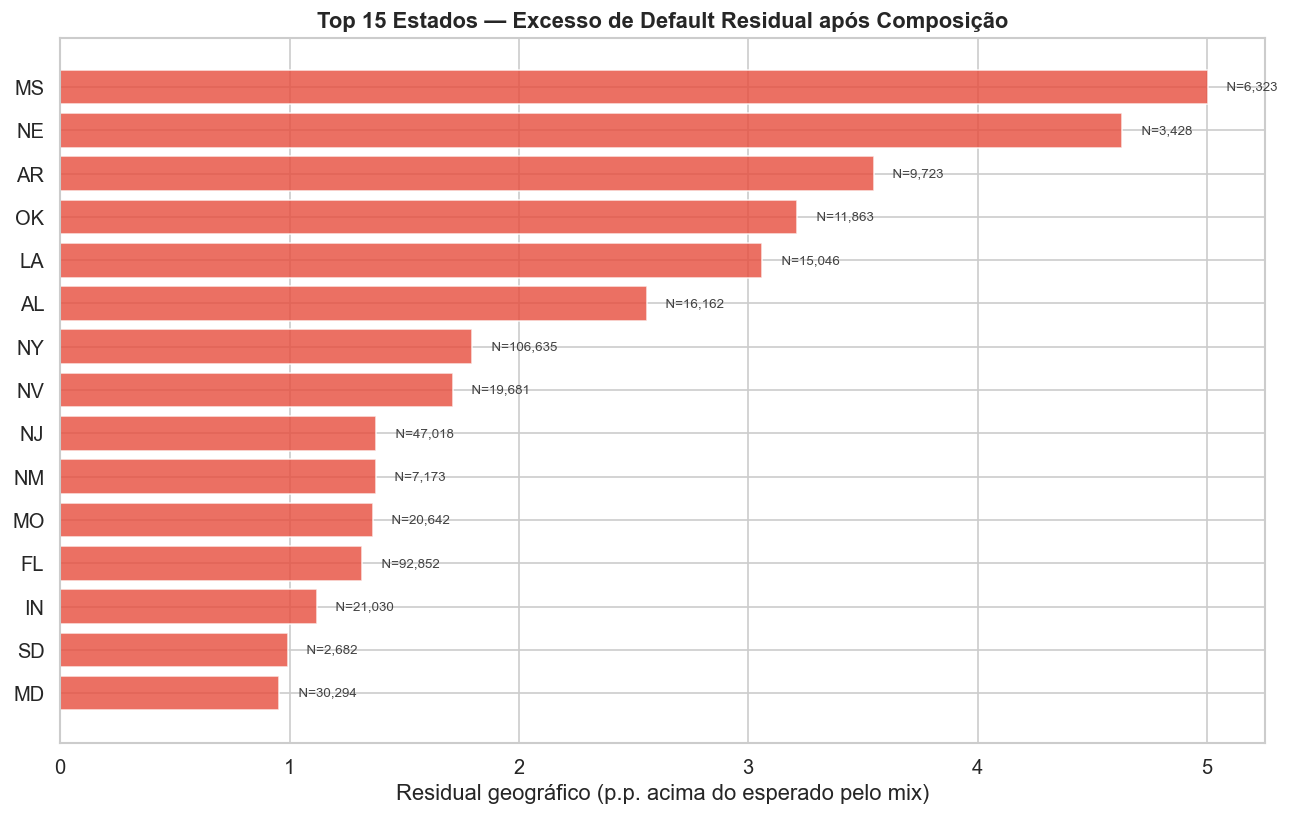

=== Estados ENGANOSOS — parecem ruins no bruto, mas o residual geográfico é neutro/bom ===
(rank_bruto baixo = pior no bruto; rank_diff negativo = "exonerado" pelo controle de mix)
addr_state  default_rate_pct  expected_rate_pct  pure_geo_effect_pp  rank_bruto  rank_residual
        HI             20.30              21.46               -1.16        23.0           31.0
        ND             20.85              21.04               -0.19        20.0           28.0
        TN             21.60              20.72                0.88        10.0           16.0
        DE             20.20              20.46               -0.26        24.0           29.0
        IN             21.64              20.52                1.12         9.0           13.0


In [13]:
1# ── 2.7.3 Choropleths lado a lado: bruto vs residual geográfico ─────
# Mostra a diferença entre olhar o número cru e olhar o sinal acionável

fig_dual = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'choropleth'}, {'type': 'choropleth'}]],
    subplot_titles=('(a) Default rate BRUTO por estado<br><sub>confunde composição com efeito local</sub>',
                    '(b) Residual geográfico<br><sub>após controlar pelo mix de grade — sinal de monitoramento</sub>'),
    horizontal_spacing=0.05
)

# (a) Default rate bruto
fig_dual.add_trace(
    go.Choropleth(
        locations=geo_decomp['addr_state'],
        z=geo_decomp['default_rate_pct'],
        locationmode='USA-states',
        colorscale='Reds',
        zmin=geo_decomp['default_rate_pct'].min(),
        zmax=geo_decomp['default_rate_pct'].max(),
        colorbar=dict(title='%', x=0.46, len=0.8, thickness=12),
        hovertemplate='<b>%{location}</b><br>Default bruto: %{z:.2f}%<extra></extra>',
    ),
    row=1, col=1
)

# (b) Residual geográfico
fig_dual.add_trace(
    go.Choropleth(
        locations=geo_decomp['addr_state'],
        z=geo_decomp['pure_geo_effect_pp'],
        locationmode='USA-states',
        colorscale='RdBu_r',
        zmid=0,
        zmin=-3, zmax=3,
        colorbar=dict(title='p.p.', x=1.0, len=0.8, thickness=12),
        hovertemplate='<b>%{location}</b><br>Residual geográfico: %{z:+.2f} p.p.<extra></extra>',
    ),
    row=1, col=2
)

fig_dual.update_geos(scope='usa', row=1, col=1)
fig_dual.update_geos(scope='usa', row=1, col=2)
fig_dual.update_layout(
    height=480,
    margin=dict(l=0, r=0, t=80, b=0),
    title_text='<b>Mapa de Risco Geográfico — duas leituras do mesmo dado</b>',
    title_x=0.5
)
fig_dual.show()
fig_dual.write_html('../assets/13_mapa_geo_dual.html')

# Ranking horizontal: piores 15 estados por residual geográfico
worst15 = geo_decomp.nlargest(15, 'pure_geo_effect_pp').sort_values('pure_geo_effect_pp')
fig, ax = plt.subplots(figsize=(11, 7))
colors_geo = ['#e74c3c' if x > 0 else '#2ecc71' for x in worst15['pure_geo_effect_pp']]
ax.barh(worst15['addr_state'], worst15['pure_geo_effect_pp'], color=colors_geo, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual geográfico (p.p. acima do esperado pelo mix)')
ax.set_title('Top 15 Estados — Excesso de Default Residual após Composição',
             fontweight='bold')
for i, (state, val, n) in enumerate(zip(worst15['addr_state'],
                                          worst15['pure_geo_effect_pp'],
                                          worst15['n_loans'])):
    ax.text(val + (0.05 if val > 0 else -0.05), i, f'  N={n:,}',
            va='center', ha='left' if val > 0 else 'right', fontsize=8, color='#444')
plt.tight_layout()
plt.savefig('../assets/13b_ranking_geo_efeito_residual.png', bbox_inches='tight')
plt.show()

# Diferença visual: estados onde bruto sugere "ruim" mas residual geográfico é neutro/bom
geo_decomp['rank_bruto']    = geo_decomp['default_rate_pct'].rank(ascending=False)
geo_decomp['rank_residual']     = geo_decomp['pure_geo_effect_pp'].rank(ascending=False)
geo_decomp['rank_diff']     = geo_decomp['rank_bruto'] - geo_decomp['rank_residual']
print('=== Estados ENGANOSOS — parecem ruins no bruto, mas o residual geográfico é neutro/bom ===')
print('(rank_bruto baixo = pior no bruto; rank_diff negativo = "exonerado" pelo controle de mix)')
print(geo_decomp.nsmallest(5, 'rank_diff')[
    ['addr_state','default_rate_pct','expected_rate_pct','pure_geo_effect_pp','rank_bruto','rank_residual']
].round(2).to_string(index=False))


---
## Seção 2.8 — Renda × Verificação: um caso de viés de seleção

Esta seção começou com a hipótese de que renda autodeclarada **não-verificada** teria viés de
superdeclaração e, portanto, pior performance. **Os dados refutam a hipótese** — e o motivo é
metodologicamente importante.

### O que os dados mostram

Em **todas** as faixas de renda, empréstimos `Not Verified` têm a **menor** taxa de inadimplência
e `Verified` a **maior** — o oposto do esperado.

### Por que: `verification_status` é uma variável endógena

O Lending Club **não verificava a renda aleatoriamente**. A verificação era exigida com mais
frequência justamente para os pedidos que já exibiam sinais de risco. Portanto:

- `verification_status` é **consequência** de uma triagem de risco anterior do próprio LC —
  não uma causa independente.
- "Verificado" funciona como um *marcador* de que o LC já havia desconfiado daquele borrower.
- A correlação verificação → inadimplência é **viés de seleção**, não efeito causal.

Isso torna `verification_status` quase um vazamento (*leakage*) suave: carrega informação de
uma decisão downstream do LC. **Conclusão metodológica:** não se pode usar `verification_status`
como feature protetora num modelo, nem concluir que *tornar a verificação obrigatória* reduziria
risco — a relação observada é seleção, e mexer na política não move a causa.

> Por isso `verification_status` **não entra** na combinação tóxica da Seção 6.4 nem nas
> recomendações da Seção 7. É mantido apenas como variável descritiva no export do Looker.

**Faixas de renda usadas:** `<$40k`, `$40k-60k`, `$60k-100k`, `$100k-150k`, `>$150k`.


In [14]:
# ── 2.8.1 Faixas de renda × default rate ────────────────────
df['income_bucket'] = pd.cut(
    df['annual_inc'],
    bins=[0, 40_000, 60_000, 100_000, 150_000, np.inf],
    labels=['<$40k', '$40k-60k', '$60k-100k', '$100k-150k', '>$150k']
)

inc_stats = (
    df.groupby('income_bucket', observed=True)
      .agg(n_loans=('default_flag','count'),
           default_rate=('default_flag','mean'),
           avg_dti=('dti','mean'),
           avg_loan=('loan_amnt','mean'))
      .reset_index()
)
inc_stats['default_rate_pct'] = inc_stats['default_rate'] * 100
print('=== Default rate por faixa de renda ===')
print(inc_stats.round(2).to_string(index=False))

# Cruzamento com verification_status
inc_verif = (
    df.groupby(['income_bucket','verification_status'], observed=True)['default_flag']
      .agg(['mean','count'])
      .reset_index()
      .rename(columns={'mean':'default_rate','count':'n'})
)
inc_verif['default_rate_pct'] = inc_verif['default_rate'] * 100
inc_verif = inc_verif[inc_verif['n'] >= 500]

pivot_iv = inc_verif.pivot(index='income_bucket', columns='verification_status',
                           values='default_rate_pct')
n_pivot_iv = inc_verif.pivot(index='income_bucket', columns='verification_status', values='n')

print('\n=== Default rate (%) por Faixa de Renda × Verificação ===')
print(pivot_iv.round(2).to_string())
print('\nN por célula:')
print(n_pivot_iv.fillna(0).astype(int).to_string())


=== Default rate por faixa de renda ===
income_bucket  n_loans  default_rate  avg_dti  avg_loan  default_rate_pct
        <$40k   238463          0.24    20.76   8290.10             23.82
     $40k-60k   361835          0.22    19.37  11969.05             21.71
    $60k-100k   463858          0.19    17.80  16032.45             19.13
   $100k-150k   173441          0.16    15.78  19982.16             16.25
       >$150k    68484          0.15    12.90  23419.27             14.73

=== Default rate (%) por Faixa de Renda × Verificação ===
verification_status  Not Verified  Source Verified  Verified
income_bucket                                               
<$40k                       18.27            24.83     28.02
$40k-60k                    15.76            23.33     26.19
$60k-100k                   13.57            20.24     23.38
$100k-150k                  11.28            17.35     18.97
>$150k                      10.68            15.30     15.74

N por célula:
verification_st

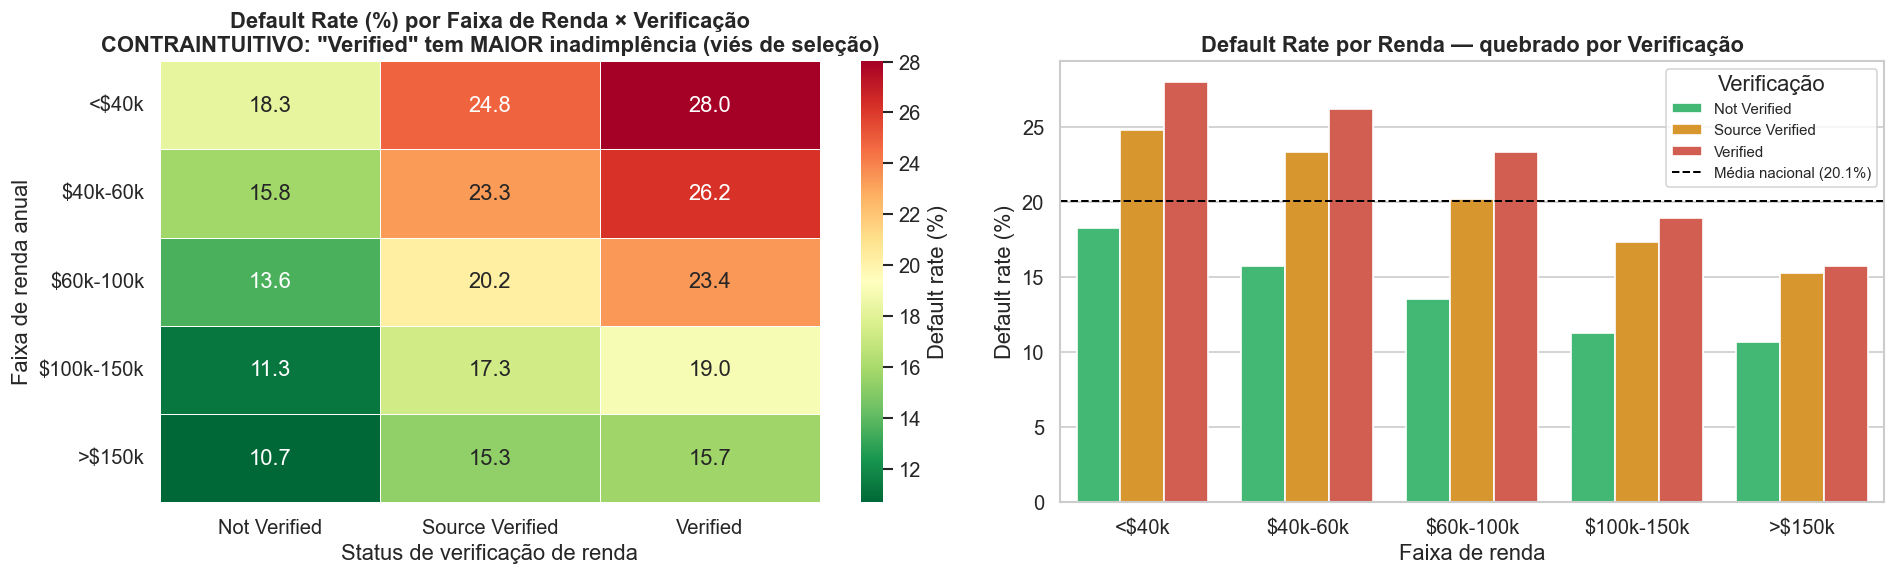

Renda >$150k NÃO-verificada:   default rate = 10.68%  (N=10,669)
Renda $60-100k VERIFICADA:       default rate = 23.38%  (N=141,378)

→ A renda alta não-verificada tem MENOR inadimplência que a renda média verificada.
  Isso NÃO significa que não-verificar é melhor: verification_status é endógeno —
  o LC verificava justamente os pedidos que já pareciam arriscados. A variável é
  um marcador de triagem de risco anterior, não uma causa. Não usar como feature
  de risco nem como base para política (ver markdown da Seção 2.8).


In [15]:
# ── 2.8.2 Visualização: faixa de renda × verificação ────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Heatmap principal
sns.heatmap(pivot_iv, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label':'Default rate (%)'})
axes[0].set_title('Default Rate (%) por Faixa de Renda × Verificação\n'
                  'CONTRAINTUITIVO: "Verified" tem MAIOR inadimplência (viés de seleção)',
                  fontweight='bold')
axes[0].set_xlabel('Status de verificação de renda')
axes[0].set_ylabel('Faixa de renda anual')

# (b) Barras agrupadas para leitura direta
sns.barplot(data=inc_verif, x='income_bucket', y='default_rate_pct',
            hue='verification_status', ax=axes[1],
            palette={'Verified':'#e74c3c','Source Verified':'#f39c12','Not Verified':'#2ecc71'})
axes[1].axhline(national_rate, color='black', linestyle='--', linewidth=1.2,
                label=f'Média nacional ({national_rate:.1f}%)')
axes[1].set_title('Default Rate por Renda — quebrado por Verificação',
                  fontweight='bold')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Faixa de renda')
axes[1].legend(title='Verificação', fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('../assets/14_renda_verificacao.png', bbox_inches='tight')
plt.show()

# Evidência do viés de seleção: 'Not Verified' é o MELHOR em todas as faixas
high_notv = df[(df['income_bucket']=='>$150k') & (df['verification_status']=='Not Verified')]['default_flag']
mid_v     = df[(df['income_bucket']=='$60k-100k') & (df['verification_status']=='Verified')]['default_flag']
print(f'Renda >$150k NÃO-verificada:   default rate = {high_notv.mean()*100:.2f}%  (N={len(high_notv):,})')
print(f'Renda $60-100k VERIFICADA:       default rate = {mid_v.mean()*100:.2f}%  (N={len(mid_v):,})')
print()
print('→ A renda alta não-verificada tem MENOR inadimplência que a renda média verificada.')
print('  Isso NÃO significa que não-verificar é melhor: verification_status é endógeno —')
print('  o LC verificava justamente os pedidos que já pareciam arriscados. A variável é')
print('  um marcador de triagem de risco anterior, não uma causa. Não usar como feature')
print('  de risco nem como base para política (ver markdown da Seção 2.8).')


---
## Seção 3 — Teste de Hipótese

**Pergunta:** Grades D e E têm taxa de inadimplência significativamente maior que os demais grades?

- **H₀:** default_rate(D+E) = default_rate(A+B+C+F+G) → diferença por acaso amostral
- **H₁:** default_rate(D+E) > default_rate(demais) → diferença estrutural

Usamos dois testes complementares:
1. **Chi-quadrado de independência** — testa se grade_group e default_flag são independentes
2. **Teste Z de proporções (unilateral)** — testa H₁ diretamente com IC 95%

**Effect size:** V de Cramér (chi²) — independente do tamanho amostral.


In [16]:
# ── 3.1 Preparar grupos ─────────────────────────────────────
df['grade_group'] = df['grade'].apply(lambda g: 'D+E' if g in ['D','E'] else 'Demais')

group_stats = (
    df.groupby('grade_group')['default_flag']
    .agg(['sum','count','mean'])
    .rename(columns={'sum':'n_default','count':'n_total','mean':'default_rate'})
)
group_stats['default_rate_pct'] = group_stats['default_rate'] * 100
print('=== Estatísticas por grupo ===')
print(group_stats)


=== Estatísticas por grupo ===
             n_default  n_total  default_rate  default_rate_pct
grade_group                                                    
D+E              95172   288089      0.330356         33.035624
Demais          167275  1018298      0.164269         16.426920


In [17]:
# ── 3.2 Teste Chi-quadrado ──────────────────────────────────
contingency = pd.crosstab(df['grade_group'], df['default_flag'])
print('Tabela de contingência:')
print(contingency)

chi2, p_chi2, dof, expected = chi2_contingency(contingency)

n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f'\nChi² = {chi2:,.2f}  |  p-valor = {p_chi2:.2e}  |  gl = {dof}')
print(f'V de Cramér = {cramers_v:.4f}')
print(f'  → {"Efeito pequeno" if cramers_v < 0.1 else "Efeito médio" if cramers_v < 0.3 else "Efeito grande"}')


Tabela de contingência:
default_flag       0       1
grade_group                 
D+E           192917   95172
Demais        851023  167275

Chi² = 38,584.79  |  p-valor = 0.00e+00  |  gl = 1
V de Cramér = 0.1719
  → Efeito médio


In [18]:
# ── 3.3 Teste Z de proporções (unilateral: D+E > Demais) ────
n_de    = group_stats.loc['D+E', 'n_total']
x_de    = group_stats.loc['D+E', 'n_default']
p_de    = group_stats.loc['D+E', 'default_rate']

n_outros = group_stats.loc['Demais', 'n_total']
x_outros = group_stats.loc['Demais', 'n_default']
p_outros = group_stats.loc['Demais', 'default_rate']

# Z-score
p_pool = (x_de + x_outros) / (n_de + n_outros)
se     = np.sqrt(p_pool * (1 - p_pool) * (1/n_de + 1/n_outros))
z_stat = (p_de - p_outros) / se
p_val_z = 1 - norm.cdf(z_stat)

# IC 95% para a diferença
diff = p_de - p_outros
se_diff = np.sqrt(p_de*(1-p_de)/n_de + p_outros*(1-p_outros)/n_outros)
ci_low  = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print('=== Teste Z de proporções (H₁: D+E > Demais) ===')
print(f'p(D+E)    = {p_de*100:.2f}%  (N = {n_de:,})')
print(f'p(Demais) = {p_outros*100:.2f}%  (N = {n_outros:,})')
print(f'Diferença = {diff*100:.2f} p.p.')
print(f'IC 95%    = [{ci_low*100:.2f}, {ci_high*100:.2f}] p.p.')
print(f'Z = {z_stat:.4f}  |  p-valor (unilateral) = {p_val_z:.2e}')
print()
if p_val_z < 0.01:
    print('✓ Rejeitamos H₀ ao nível 1%. Grades D+E têm default rate estruturalmente maior.')


=== Teste Z de proporções (H₁: D+E > Demais) ===
p(D+E)    = 33.04%  (N = 288,089)
p(Demais) = 16.43%  (N = 1,018,298)
Diferença = 16.61 p.p.
IC 95%    = [16.42, 16.79] p.p.
Z = 196.4327  |  p-valor (unilateral) = 0.00e+00

✓ Rejeitamos H₀ ao nível 1%. Grades D+E têm default rate estruturalmente maior.


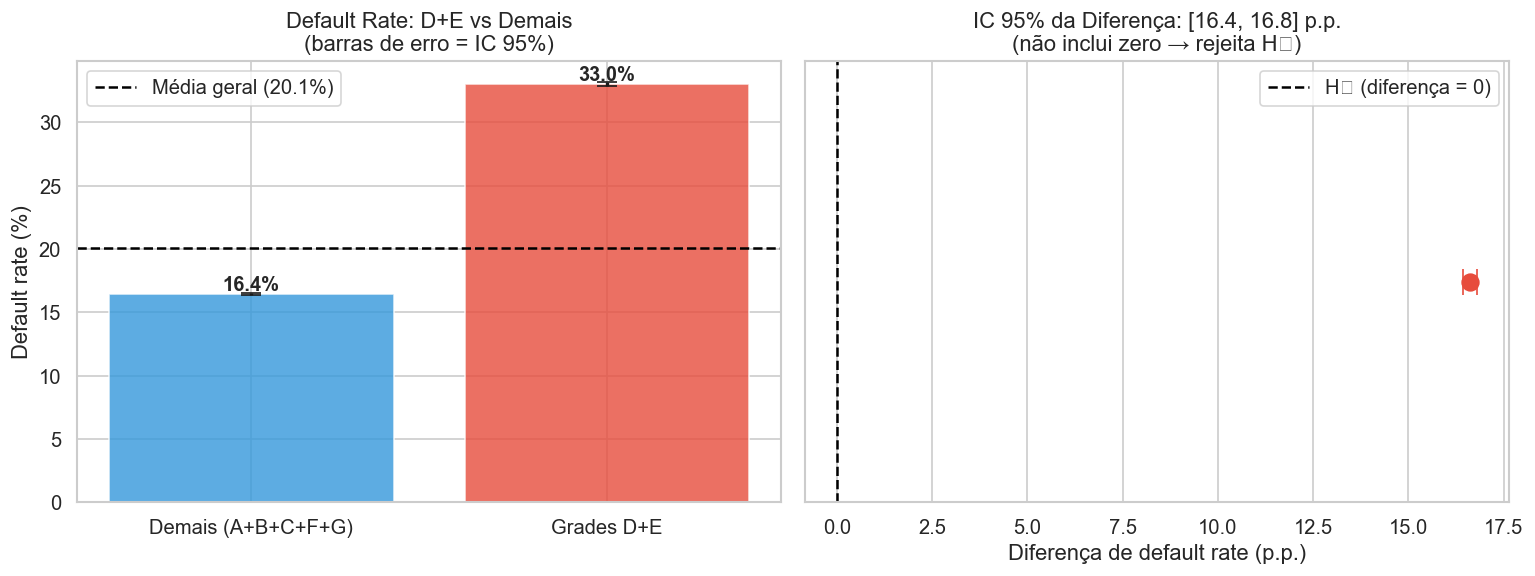

In [19]:
# ── 3.4 Visualização do resultado ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras de default rate com IC
rates  = [p_outros*100, p_de*100]
labels = ['Demais (A+B+C+F+G)', 'Grades D+E']
errors = [1.96*np.sqrt(p_outros*(1-p_outros)/n_outros)*100,
          1.96*np.sqrt(p_de*(1-p_de)/n_de)*100]
colors_bar = ['#3498db', '#e74c3c']

bars_ax = axes[0].bar(labels, rates, color=colors_bar, alpha=0.8, yerr=errors,
                      capsize=6, error_kw={'linewidth':2})
axes[0].axhline(df['default_flag'].mean()*100, color='black', linestyle='--',
                label=f'Média geral ({df["default_flag"].mean()*100:.1f}%)')
axes[0].set_ylabel('Default rate (%)')
axes[0].set_title('Default Rate: D+E vs Demais\n(barras de erro = IC 95%)')
axes[0].legend()
for bar, rate in zip(bars_ax, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Intervalo de confiança da diferença
x = np.array([diff*100])
axes[1].errorbar(x, [0], xerr=[[( diff - ci_low)*100], [(ci_high - diff)*100]],
                 fmt='o', color='#e74c3c', markersize=10, capsize=8, linewidth=2.5)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='H₀ (diferença = 0)')
axes[1].set_xlabel('Diferença de default rate (p.p.)')
axes[1].set_title(f'IC 95% da Diferença: [{ci_low*100:.1f}, {ci_high*100:.1f}] p.p.\n(não inclui zero → rejeita H₀)')
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/07_hipotese.png', bbox_inches='tight')
plt.show()


---
## Seção 4 — Decomposição: Mix vs Deterioração

A inadimplência agregada pode piorar por dois mecanismos distintos:

1. **Efeito de Mix:** o volume de empréstimos de alto risco (Grades D+E) cresceu como proporção
   da carteira → mesmo que cada grade mantenha sua taxa, a média sobe porque pesa mais os ruins.

2. **Efeito de Deterioração:** a taxa dentro de cada grade piorou — os próprios Grades D+E
   estão gerando mais inadimplência do que antes.

Separar esses efeitos é crítico para política de crédito:
- Se é **mix**, a solução é restringir volume de D+E
- Se é **deterioração**, a solução é revisar os critérios dentro de D+E


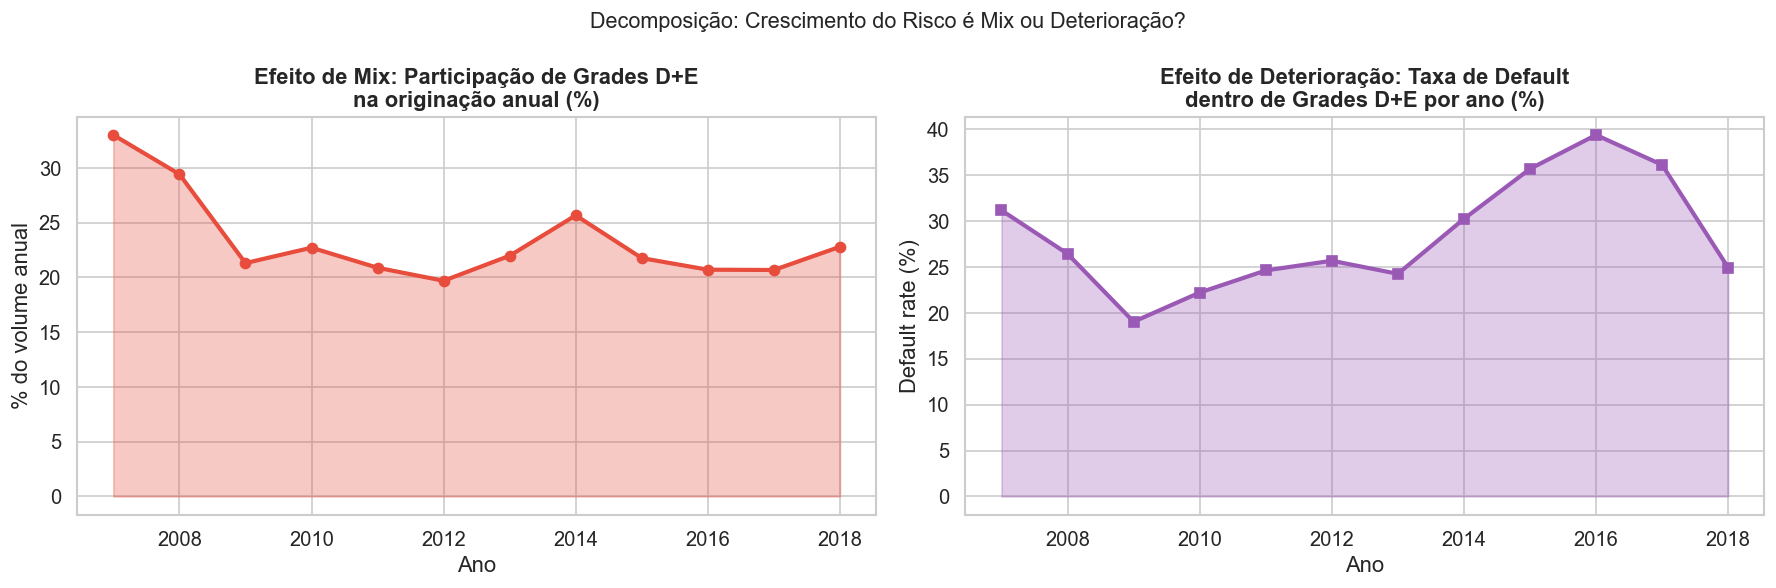

In [20]:
# ── 4.1 Evolução do mix (participação de D+E por ano) ────────
yearly = (
    df.dropna(subset=['issue_year'])
    .groupby(['issue_year', 'grade_group'])
    .size()
    .reset_index(name='n')
)
yearly_total = yearly.groupby('issue_year')['n'].transform('sum')
yearly['share'] = yearly['n'] / yearly_total * 100
yearly_de = yearly[yearly['grade_group'] == 'D+E']

# Evolução da taxa dentro de D+E
rate_de_yearly = (
    df[df['grade_group'] == 'D+E']
    .dropna(subset=['issue_year'])
    .groupby('issue_year')['default_flag']
    .agg(['mean','count'])
    .reset_index()
)
rate_de_yearly.columns = ['issue_year','default_rate','n']
rate_de_yearly['default_rate_pct'] = rate_de_yearly['default_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Mix effect
axes[0].fill_between(yearly_de['issue_year'], yearly_de['share'],
                     alpha=0.3, color='#e74c3c')
axes[0].plot(yearly_de['issue_year'], yearly_de['share'],
             marker='o', color='#e74c3c', linewidth=2.5)
axes[0].set_title('Efeito de Mix: Participação de Grades D+E\nna originação anual (%)', fontweight='bold')
axes[0].set_ylabel('% do volume anual')
axes[0].set_xlabel('Ano')

# Deterioration effect
axes[1].fill_between(rate_de_yearly['issue_year'], rate_de_yearly['default_rate_pct'],
                     alpha=0.3, color='#9b59b6')
axes[1].plot(rate_de_yearly['issue_year'], rate_de_yearly['default_rate_pct'],
             marker='s', color='#9b59b6', linewidth=2.5)
axes[1].set_title('Efeito de Deterioração: Taxa de Default\ndentro de Grades D+E por ano (%)', fontweight='bold')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Ano')

plt.suptitle('Decomposição: Crescimento do Risco é Mix ou Deterioração?', fontsize=13)
plt.tight_layout()
plt.savefig('../assets/08_decomposicao.png', bbox_inches='tight')
plt.show()


=== Decomposição por ano ===
 year  real  expected_fixed_mix  share_de
 2007 26.20               26.20     33.00
 2008 20.73               21.02     29.42
 2009 13.69               14.48     21.30
 2010 14.01               15.10     22.71
 2011 15.18               16.62     20.88
 2012 16.20               17.77     19.69
 2013 15.60               16.82     21.97
 2014 18.54               19.69     25.66
 2015 20.16               22.39     21.76
 2016 24.27               26.61     20.70
 2017 22.90               24.95     20.67
 2018 14.73               16.08     22.79


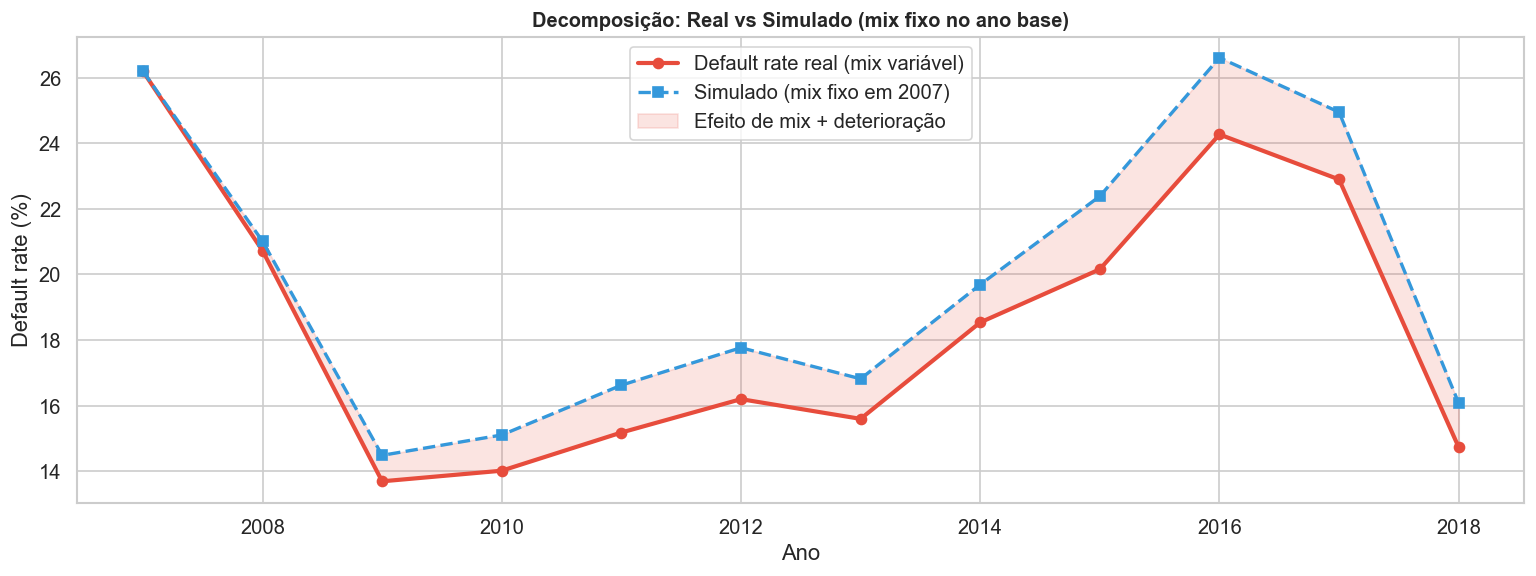

In [21]:
# ── 4.2 Decomposição Oaxaca-Blinder simplificada ─────────────
# Compara default rate esperado (com mix t=0) vs realizado

years_valid = sorted(df['issue_year'].dropna().unique().astype(int))
first_yr = years_valid[0]

# Participação de D+E no primeiro ano (baseline)
mix_base = df[df['issue_year'] == first_yr]['grade_group'].value_counts(normalize=True)
share_de_base = mix_base.get('D+E', 0)

results = []
for yr in years_valid:
    sub = df[df['issue_year'] == yr]
    share_de  = (sub['grade_group'] == 'D+E').mean()
    rate_de   = sub[sub['grade_group']=='D+E']['default_flag'].mean() if (sub['grade_group']=='D+E').any() else 0
    rate_out  = sub[sub['grade_group']=='Demais']['default_flag'].mean() if (sub['grade_group']=='Demais').any() else 0
    rate_real = sub['default_flag'].mean()
    rate_expected = share_de_base * rate_de + (1 - share_de_base) * rate_out
    results.append({'year': yr, 'real': rate_real*100, 'expected_fixed_mix': rate_expected*100,
                    'share_de': share_de*100})

decomp = pd.DataFrame(results)
print('=== Decomposição por ano ===')
print(decomp.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(decomp['year'], decomp['real'], marker='o', color='#e74c3c',
        linewidth=2.5, label='Default rate real (mix variável)')
ax.plot(decomp['year'], decomp['expected_fixed_mix'], marker='s', linestyle='--',
        color='#3498db', linewidth=2, label=f'Simulado (mix fixo em {first_yr})')
ax.fill_between(decomp['year'], decomp['expected_fixed_mix'], decomp['real'],
                alpha=0.15, color='#e74c3c', label='Efeito de mix + deterioração')
ax.set_title('Decomposição: Real vs Simulado (mix fixo no ano base)', fontweight='bold', fontsize=12)
ax.set_ylabel('Default rate (%)')
ax.set_xlabel('Ano')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/09_decomposicao_oaxaca.png', bbox_inches='tight')
plt.show()


---
## Seção 5 — Regressão Logística

**Objetivo:** Quantificar o efeito marginal de cada fator sobre a probabilidade de inadimplência,
controlando pelos demais. Interpretamos via **odds ratios** — não via métricas de ML.

**Escopo do modelo:** A regressão logística aqui é uma ferramenta explicativa para estimar associações controladas entre variáveis disponíveis na originação e inadimplência. Ela não é apresentada como modelo final de produção; um modelo produtivo exigiria validação temporal, calibração, monitoramento de drift, análise de estabilidade e avaliação de fairness.

**Variável dependente:** `default_flag` (1 = inadimplente)

**Variáveis independentes (todas disponíveis na originação):**
- `grade` (categórica — referência: A)
- `dti` (contínua)
- `term` (36 ou 60 meses)
- `purpose` (categórica — referência: car)
- `annual_inc_w` (contínua, winsorizada)

**Desbalanceamento:** ~80/20. Para esta regressão inferencial em `statsmodels`, não aplicamos balanceamento de classe nem SMOTE.
O objetivo é estimar associações ajustadas via odds ratios; o desbalanceamento é reportado como característica da amostra, não corrigido na função de perda.

> **Extensões desta versão avançada:** as Seções 5.4–5.6 abaixo respondem exatamente às lacunas
> apontadas acima — validação temporal fora de amostra (5.4), calibração probabilística (5.5) e
> tradução dos coeficientes em efeitos marginais/elasticidade para comitê de crédito (5.6).
> A Seção 6 acrescenta análise de sobrevivência, o enquadramento natural de um problema tempo-até-evento.


In [22]:
# ── 5.1 Preparar features ────────────────────────────────────
df_model = df.dropna(subset=['grade','dti','term','purpose','annual_inc_w']).copy()

# Dummies
dummies = pd.get_dummies(df_model[['grade','purpose']], drop_first=True)
X = pd.concat([
    dummies,
    pd.get_dummies(df_model['term'], prefix='term', drop_first=True),
    df_model[['dti','annual_inc_w']].rename(columns={'annual_inc_w':'annual_inc'})
], axis=1).astype(float)

y = df_model['default_flag'].values

print(f'X shape: {X.shape}  |  Positivos: {y.mean()*100:.1f}%')
print(f'Features ({X.shape[1]}):')
for col in X.columns: print(f'  {col}')


X shape: (1306071, 22)  |  Positivos: 20.1%
Features (22):
  grade_B
  grade_C
  grade_D
  grade_E
  grade_F
  grade_G
  purpose_credit_card
  purpose_debt_consolidation
  purpose_educational
  purpose_home_improvement
  purpose_house
  purpose_major_purchase
  purpose_medical
  purpose_moving
  purpose_other
  purpose_renewable_energy
  purpose_small_business
  purpose_vacation
  purpose_wedding
  term_60
  dti
  annual_inc


In [23]:
# ── 5.2 Fit com statsmodels (odds ratios + IC) ───────────────
X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm)
result = logit.fit(disp=0, maxiter=200)

# Odds ratios
params     = result.params
conf       = result.conf_int()
odds_ratio = np.exp(params)
ci_low_or  = np.exp(conf[0])
ci_high_or = np.exp(conf[1])
pvals      = result.pvalues

or_df = pd.DataFrame({
    'odds_ratio': odds_ratio,
    'ci_low':     ci_low_or,
    'ci_high':    ci_high_or,
    'p_value':    pvals
}).drop('const').sort_values('odds_ratio', ascending=False)

print('=== Odds Ratios (top 15) ===')
print(or_df.head(15).round(4))


=== Odds Ratios (top 15) ===
                            odds_ratio  ci_low  ci_high  p_value
grade_G                         9.6608  9.2278  10.1141   0.0000
grade_F                         8.2399  7.9995   8.4876   0.0000
grade_E                         6.6843  6.5314   6.8407   0.0000
grade_D                         5.1938  5.0883   5.3015   0.0000
grade_C                         3.6750  3.6046   3.7468   0.0000
grade_B                         2.1717  2.1293   2.2150   0.0000
purpose_small_business          1.7303  1.6288   1.8380   0.0000
term_60                         1.5712  1.5547   1.5879   0.0000
purpose_educational             1.4639  1.1423   1.8760   0.0026
purpose_medical                 1.3106  1.2312   1.3951   0.0000
purpose_renewable_energy        1.3100  1.1106   1.5453   0.0014
purpose_moving                  1.3000  1.2131   1.3931   0.0000
purpose_major_purchase          1.2588  1.1888   1.3330   0.0000
purpose_debt_consolidation      1.2236  1.1657   1.2844   0.0

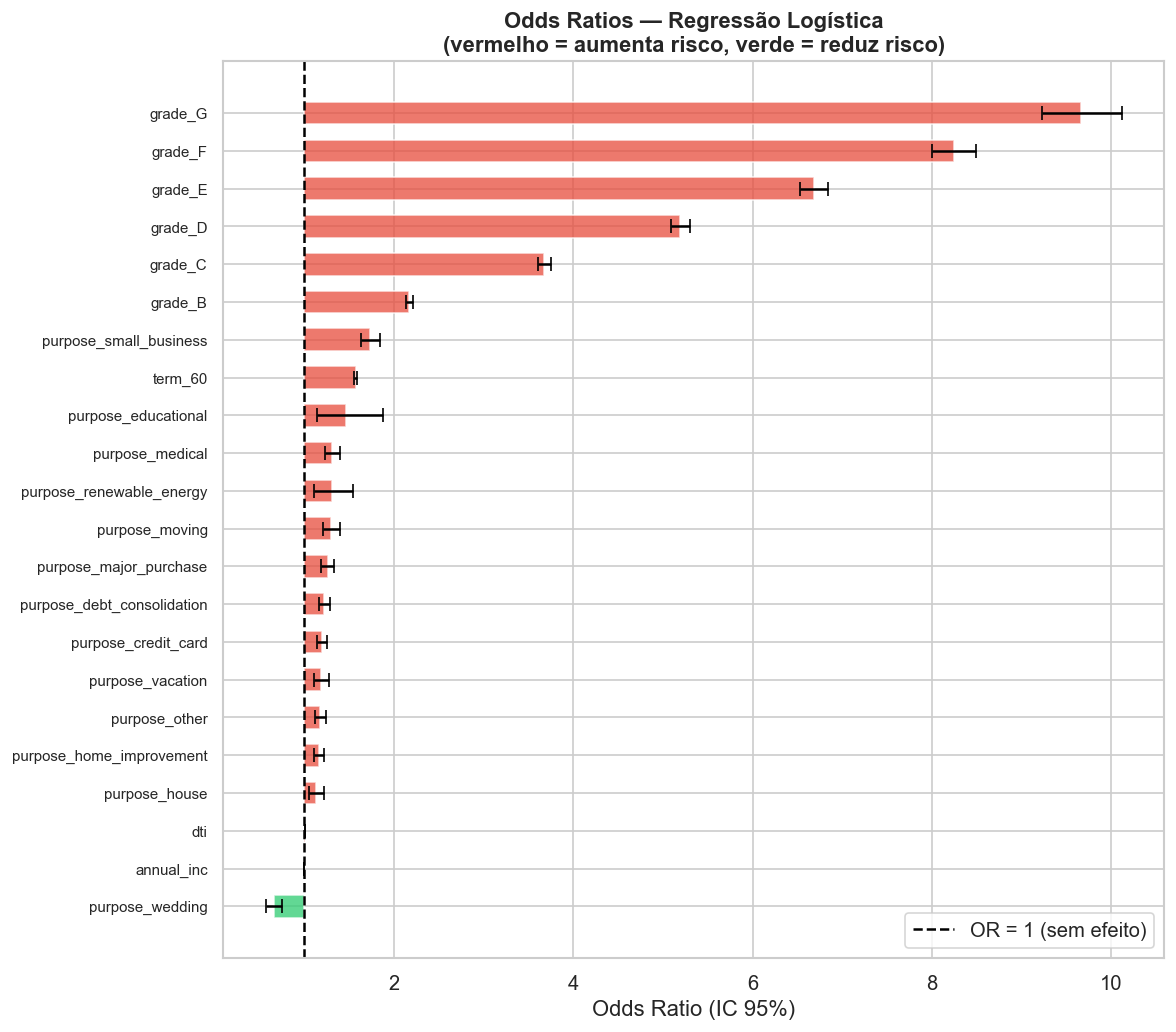


Interpretação dos top 5 fatores de risco:
  grade_G: OR=9.661 → aumenta chances de default em 866.1%
  grade_F: OR=8.240 → aumenta chances de default em 724.0%
  grade_E: OR=6.684 → aumenta chances de default em 568.4%
  grade_D: OR=5.194 → aumenta chances de default em 419.4%
  grade_C: OR=3.675 → aumenta chances de default em 267.5%


In [24]:
# ── 5.3 Forest plot de odds ratios ───────────────────────────
plot_df = or_df[or_df['p_value'] < 0.05].copy()
plot_df = plot_df.sort_values('odds_ratio')

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df)*0.4)))

colors_or = ['#e74c3c' if or_ > 1 else '#2ecc71' for or_ in plot_df['odds_ratio']]

ax.barh(plot_df.index, plot_df['odds_ratio'] - 1,
        left=1, color=colors_or, alpha=0.75, height=0.6)
ax.errorbar(plot_df['odds_ratio'], range(len(plot_df)),
            xerr=[plot_df['odds_ratio'] - plot_df['ci_low'],
                  plot_df['ci_high'] - plot_df['odds_ratio']],
            fmt='none', color='black', capsize=4, linewidth=1.5)

ax.axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (sem efeito)')
ax.set_xlabel('Odds Ratio (IC 95%)')
ax.set_title('Odds Ratios — Regressão Logística\n(vermelho = aumenta risco, verde = reduz risco)',
             fontweight='bold')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig('../assets/10_odds_ratio.png', bbox_inches='tight')
plt.show()

print('\nInterpretação dos top 5 fatores de risco:')
for name, row in or_df.head(5).iterrows():
    direction = 'aumenta' if row['odds_ratio'] > 1 else 'reduz'
    pct = abs(row['odds_ratio'] - 1) * 100
    print(f'  {name}: OR={row["odds_ratio"]:.3f} → {direction} chances de default em {pct:.1f}%')


### 5.4 — Validação temporal: treino 2007–2015 × teste 2016–2018

Avaliar um modelo de crédito no mesmo período em que foi treinado superestima sua performance:
o modelo já "viu" o regime macroeconômico daquele intervalo. A prova honesta é **out-of-time** —
treinar nas safras antigas e validar nas recentes, medindo a **degradação**.

Reportamos AUC (poder de ordenação) e Brier score (erro probabilístico) em treino e teste.
Uma queda de AUC entre os dois é esperada e informativa: quantifica o quanto o modelo perde
ao enfrentar safras que não conhece — mais útil para decisão do que um único número no período cheio.

Treino (2007–2015):   825,569 loans  |  default rate 18.5%
Teste  (2016–2018):   480,502 loans  |  default rate 22.9%

                   AUC     Brier
Treino          0.7060    0.1378
Teste           0.6841    0.1660
Degradação      0.0219  (queda de AUC out-of-time)


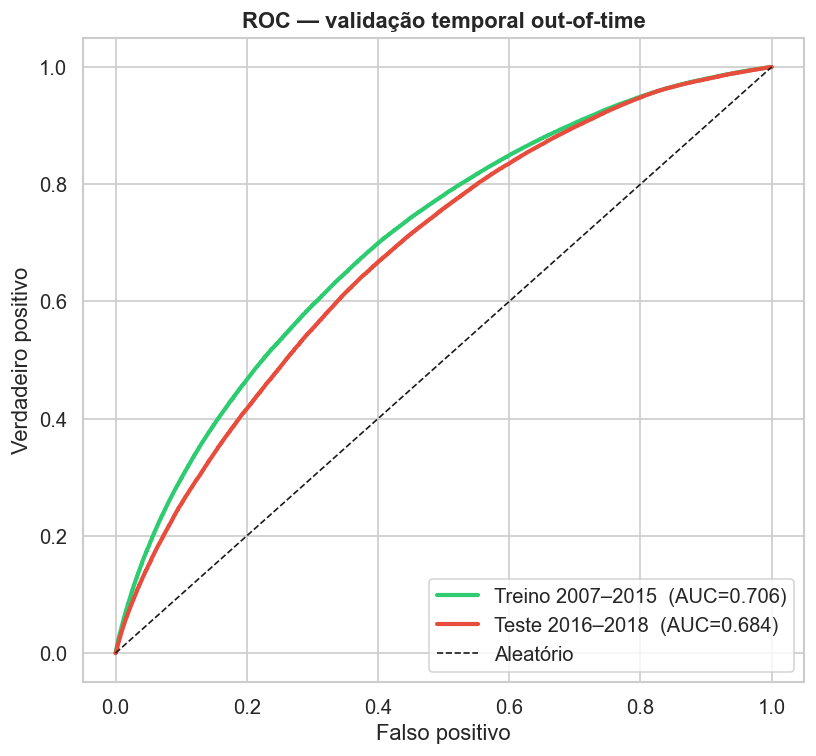

In [25]:
# ── 5.4 Validação temporal: treino (2007–2015) × teste (2016–2018) ──
split_year = df_model['issue_year'].astype('Int64')
train_mask = (split_year <= 2015).fillna(False).values
test_mask  = (split_year >= 2016).fillna(False).values

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Treino (2007–2015): {len(y_train):>9,} loans  |  default rate {y_train.mean()*100:.1f}%')
print(f'Teste  (2016–2018): {len(y_test):>9,} loans  |  default rate {y_test.mean()*100:.1f}%')

# Refit apenas no recorte de treino
Xtr_sm = sm.add_constant(X_train)
Xte_sm = sm.add_constant(X_test, has_constant='add')
logit_train = sm.Logit(y_train, Xtr_sm).fit(disp=0, maxiter=200)

p_train = logit_train.predict(Xtr_sm)
p_test  = logit_train.predict(Xte_sm)

auc_train,   auc_test   = roc_auc_score(y_train, p_train),   roc_auc_score(y_test, p_test)
brier_train, brier_test = brier_score_loss(y_train, p_train), brier_score_loss(y_test, p_test)

print(f'\n{"":12s} {"AUC":>9s} {"Brier":>9s}')
print(f'{"Treino":12s} {auc_train:9.4f} {brier_train:9.4f}')
print(f'{"Teste":12s} {auc_test:9.4f} {brier_test:9.4f}')
print(f'{"Degradação":12s} {auc_train-auc_test:9.4f}  (queda de AUC out-of-time)')

# Curvas ROC treino × teste
fig, ax = plt.subplots(figsize=(7, 6.5))
for label, yv, pv, c in [('Treino 2007–2015', y_train, p_train, '#2ecc71'),
                         ('Teste 2016–2018',  y_test,  p_test,  '#e74c3c')]:
    fpr, tpr, _ = roc_curve(yv, pv)
    ax.plot(fpr, tpr, color=c, lw=2.5, label=f'{label}  (AUC={roc_auc_score(yv,pv):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
ax.set_xlabel('Falso positivo'); ax.set_ylabel('Verdadeiro positivo')
ax.set_title('ROC — validação temporal out-of-time', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../assets/16_validacao_temporal.png', bbox_inches='tight')
plt.show()

**Leitura — validação temporal**

O modelo treinado em 2007–2015 e validado em 2016–2018 mantém **bom poder de ordenação fora
do tempo**: o AUC cai de **0,706 para 0,684** — degradação de apenas 2,2 pontos. O ranking de
risco é robusto; o modelo continua separando bons de maus pagadores em safras que nunca viu.

O alerta está no **Brier score**, que piora de **0,138 para 0,166**. A razão é direta: a
inadimplência das safras de teste (**22,9%**) é estruturalmente maior que a do treino
(**18,5%**). O modelo aprendeu um regime de risco mais brando do que o que encontrou — por
isso erra para baixo o *nível* da probabilidade, mesmo acertando a *ordem*.

**Implicação para o comitê:** um modelo reaproveitado de safras antigas continua útil para
*rankear* e priorizar, mas suas probabilidades absolutas precisam ser recalibradas antes de
alimentar provisão, pricing ou capital econômico — é exatamente o que a Seção 5.5 mede.

### 5.5 — Calibração probabilística

AUC mede **ordenação** — se os piores loans recebem score maior que os melhores. Não diz se
`P(default) = 0,30` significa que 30% daquele segmento de fato inadimple. Um modelo de crédito
sério precisa de probabilidades **calibradas**: provisão, pricing e capital econômico dependem
do nível absoluto da probabilidade, não só do ranking.

O **diagrama de confiabilidade** abaixo, traçado no recorte de teste (2016–2018), compara a
probabilidade prevista média com o default rate observado por decil de score. A diagonal é a
calibração perfeita. Incluímos uma recalibração **isotônica** como referência do ganho possível —
não como modelo final.

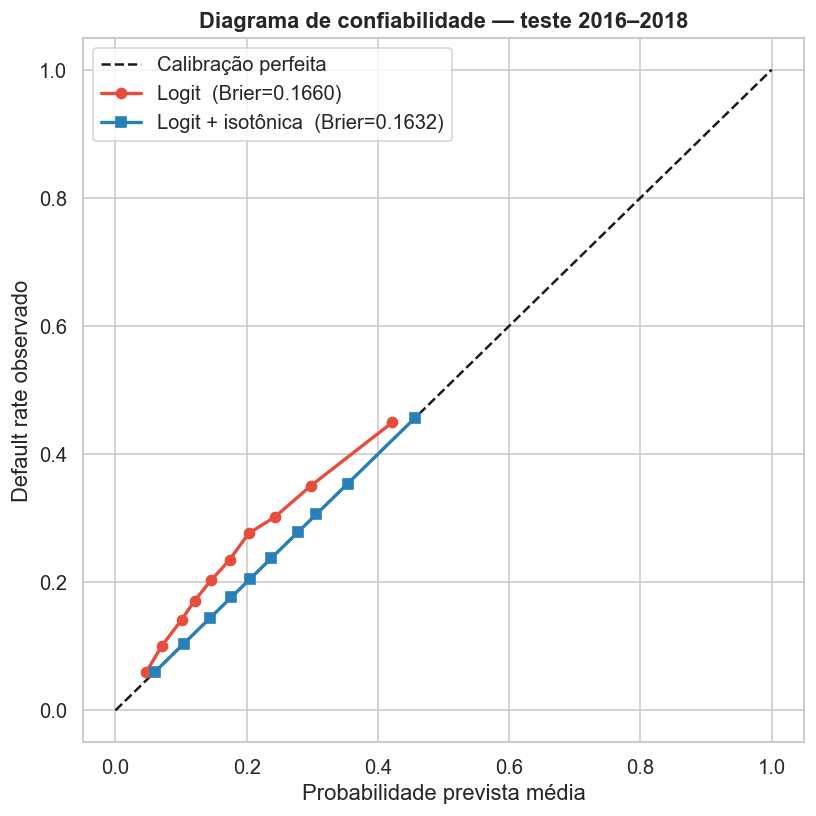

Calibração por decil de score (teste):
 prob_prevista_media  default_observado    gap
              0.0469             0.0596 0.0128
              0.0704             0.1002 0.0298
              0.1010             0.1417 0.0407
              0.1205             0.1711 0.0506
              0.1455             0.2027 0.0572
              0.1739             0.2349 0.0610
              0.2032             0.2765 0.0733
              0.2425             0.3015 0.0589
              0.2979             0.3507 0.0527
              0.4220             0.4494 0.0275

Brier logit: 0.1660  |  Brier após isotônica: 0.1632


In [26]:
# ── 5.5 Calibração probabilística (avaliada no teste 2016–2018) ──
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')

# Recalibração isotônica — referência do ganho possível
iso = IsotonicRegression(out_of_bounds='clip')
p_test_iso = iso.fit_transform(p_test, y_test)
frac_iso, mean_iso = calibration_curve(y_test, p_test_iso, n_bins=10, strategy='quantile')
brier_iso = brier_score_loss(y_test, p_test_iso)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Calibração perfeita')
ax.plot(mean_pred, frac_pos, marker='o', color='#e74c3c', lw=2,
        label=f'Logit  (Brier={brier_test:.4f})')
ax.plot(mean_iso, frac_iso, marker='s', color='#2980b9', lw=2,
        label=f'Logit + isotônica  (Brier={brier_iso:.4f})')
ax.set_xlabel('Probabilidade prevista média')
ax.set_ylabel('Default rate observado')
ax.set_title('Diagrama de confiabilidade — teste 2016–2018', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../assets/17_calibracao.png', bbox_inches='tight')
plt.show()

calib_tbl = pd.DataFrame({'prob_prevista_media': mean_pred, 'default_observado': frac_pos})
calib_tbl['gap'] = calib_tbl['default_observado'] - calib_tbl['prob_prevista_media']
print('Calibração por decil de score (teste):')
print(calib_tbl.round(4).to_string(index=False))
print(f'\nBrier logit: {brier_test:.4f}  |  Brier após isotônica: {brier_iso:.4f}')

**Leitura — calibração**

A coluna `gap` (default observado − probabilidade prevista) é **positiva nos dez decis**: o
modelo **subestima sistematicamente o risco** nas safras de 2016–2018. O desvio chega a
**+7 p.p.** nos decis intermediários — loans pontuados em ~20% de risco inadimplem, na prática,
perto de **28%**.

A recalibração isotônica reduz o Brier de 0,166 para 0,163 — melhora real, porém modesta: ela
corrige o *nível*, não recupera poder discriminante.

**Implicação para o comitê:** usar as probabilidades cruas levaria a **subprovisionar** a
carteira recente. Antes de qualquer uso em decisão de capital é obrigatória uma camada de
recalibração, e o monitoramento de calibração deve ser **recorrente, não pontual**. A
subestimação não é um defeito do modelo — é a assinatura de um regime de risco que piorou
(ver Seção 4 e a deterioração das safras 2014–2016).

### 5.6 — Efeitos marginais e elasticidade econômica

Odds ratio é multiplicativo e pouco intuitivo fora do mundo estatístico. Um comitê de crédito
decide em **pontos percentuais de probabilidade**. O **efeito marginal médio (AME)** traduz cada
coeficiente nessa unidade: "mantendo grade, term, purpose e renda constantes, um aumento de
10 p.p. no DTI está associado a *X* p.p. a mais na probabilidade de default".

Essa é a leitura que vai para uma decisão de política de crédito — não o coeficiente bruto nem o OR.

Efeito marginal médio — variação em p.p. de P(default) por +1 unidade da variável:
                            efeito_marginal_pp  p_value
grade_G                                33.5292   0.0000
grade_F                                31.1775   0.0000
grade_E                                28.0843   0.0000
grade_D                                24.3547   0.0000
grade_C                                19.2410   0.0000
grade_B                                11.4647   0.0000
purpose_small_business                  8.1051   0.0000
term_60                                 6.6798   0.0000
purpose_educational                     5.6338   0.0026
purpose_medical                         3.9985   0.0000
purpose_renewable_energy                3.9921   0.0014
purpose_moving                          3.8786   0.0000
purpose_major_purchase                  3.4030   0.0000
purpose_debt_consolidation              2.9832   0.0000
purpose_credit_card                     2.6435   0.0000
purpose_vacation     

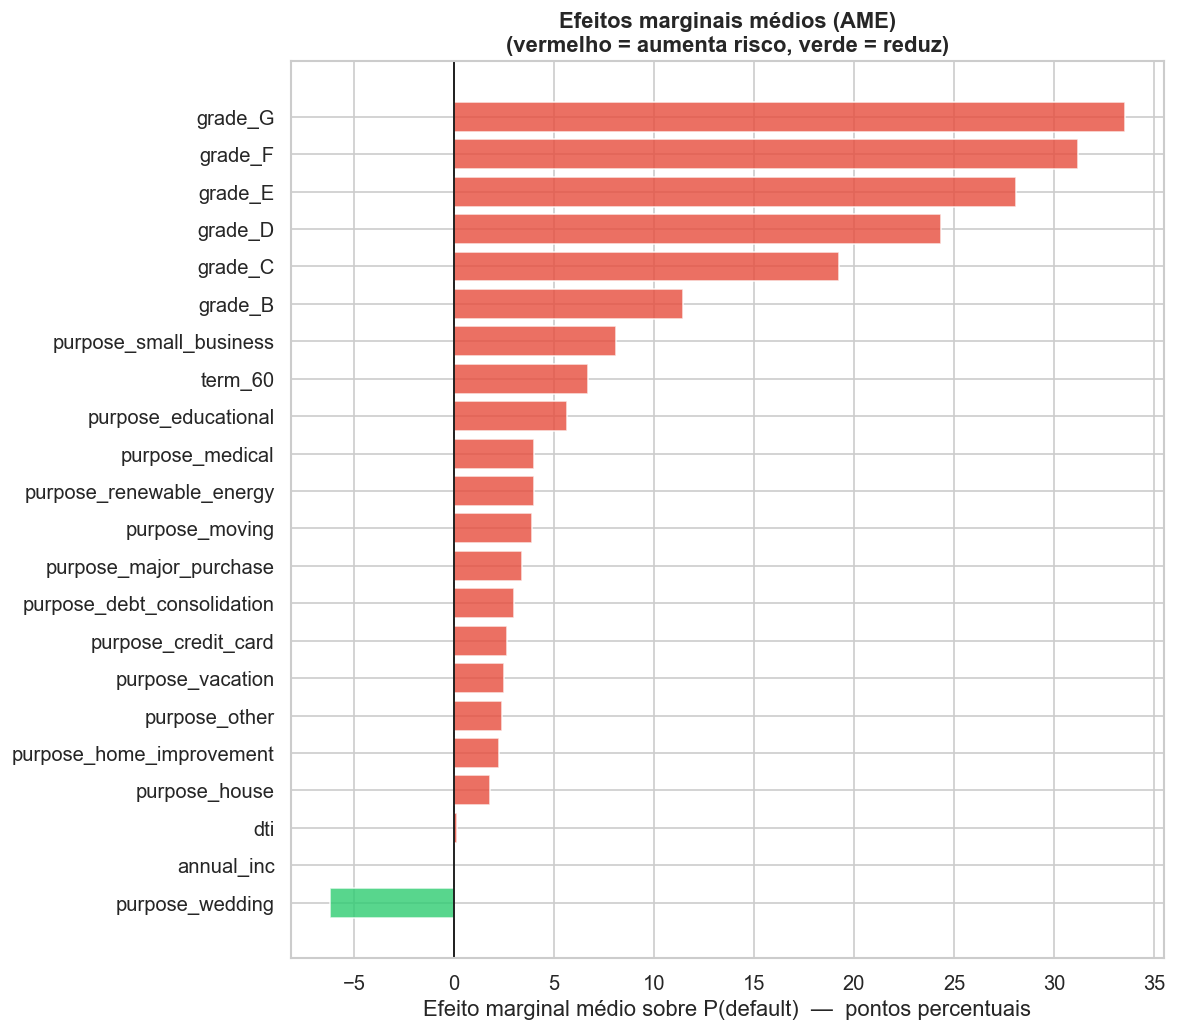

In [27]:
# ── 5.6 Efeitos marginais médios (AME) e elasticidade ────────
# Usa o modelo explicativo de período completo (result, Seção 5.2).
margeff = result.get_margeff(at='overall')
me = pd.DataFrame({
    'efeito_marginal_pp': margeff.margeff * 100,   # variação de P(default) em p.p. por +1 unidade
    'p_value':            margeff.pvalues
}, index=X.columns).sort_values('efeito_marginal_pp', ascending=False)

print('Efeito marginal médio — variação em p.p. de P(default) por +1 unidade da variável:')
print(me.round(4).to_string())

# Elasticidade prática para o comitê de crédito
ame = dict(zip(X.columns, margeff.margeff))
dti_10pp = ame['dti'] * 10 * 100
print('\n── Leitura para o comitê de crédito ──')
print(f'  DTI:  +10 p.p. no DTI  →  {dti_10pp:+.2f} p.p. na probabilidade de default,')
print(f'        mantendo grade, term, purpose e renda constantes.')
inc_10k = ame['annual_inc'] * 10_000 * 100
print(f'  Renda: +US$ 10 mil de renda anual  →  {inc_10k:+.3f} p.p. na probabilidade de default.')

# Visualização: top efeitos marginais
plot_me = me[me['p_value'] < 0.05].sort_values('efeito_marginal_pp')
fig, ax = plt.subplots(figsize=(10, max(6, len(plot_me)*0.4)))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in plot_me['efeito_marginal_pp']]
ax.barh(plot_me.index, plot_me['efeito_marginal_pp'], color=colors, alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Efeito marginal médio sobre P(default)  —  pontos percentuais')
ax.set_title('Efeitos marginais médios (AME)\n(vermelho = aumenta risco, verde = reduz)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/18_efeitos_marginais.png', bbox_inches='tight')
plt.show()

**Leitura — efeitos marginais e elasticidade**

Traduzidos em pontos percentuais de probabilidade, os coeficientes contam uma história clara:

- **Grade domina em magnitude absoluta:** sair de A para C adiciona **+19,2 p.p.** de
  probabilidade de default; de A para G, **+33,5 p.p.** — mas grade é atribuído, não negociável
  no ato do underwriting.
- **As alavancas acionáveis são term e DTI:** prazo de 60 meses adiciona **+6,7 p.p.** e cada
  **+10 p.p. de DTI**, **+1,7 p.p.** — controlando grade, purpose e renda. São as duas variáveis
  que a política de crédito *pode* mexer na aprovação.
- **Purpose importa:** `small_business` (**+8,1 p.p.**) é o uso mais arriscado; `wedding`
  (**−6,2 p.p.**), o mais protetor.
- **Renda quase não move a agulha:** +US$ 10 mil de renda anual reduz o risco em apenas
  **0,43 p.p.** — renda alta, isoladamente, não compensa term longo nem DTI elevado.

**Conexão com a tese central:** na escala de probabilidade os efeitos são aproximadamente
aditivos. Um Grade C (+19,2 p.p. sobre A) que também toma 60 meses (+6,7 p.p.) e tem DTI
elevado (≈ +3,3 p.p. para um DTI 20 pontos acima da média) acumula um excedente de risco que
o aproxima do território de Grade E (+28,1 p.p.). É a tese do CREDENCE **quantificada**: a
combinação — não o grade isolado — é o driver.

---
## Seção 6 — Análise de Sobrevivência (Tempo-até-Evento)

Crédito é, por natureza, um problema de **tempo-até-evento**: um empréstimo de 60 meses que
inadimple no mês 10 não é o mesmo que um que inadimple no mês 55, e a regressão logística —
que só enxerga o desfecho binário — não distingue os dois.

A análise de sobrevivência modela **quando** o default ocorre, tratando corretamente a
**censura à direita**: loans `Fully Paid` não são "não-eventos", são observações censuradas —
acompanhadas sem default até o fim do contrato.

- **Kaplan-Meier (6.2)** — curva de sobrevivência S(t) não-paramétrica, por term e por grade.
- **Cox de riscos proporcionais (6.3)** — hazard ratios ajustados: o efeito de cada fator sobre
  o risco *instantâneo* de default.
- **Vintage via sobrevivência (6.4)** — compara safras num horizonte comum de maturação,
  corrigindo o truncamento que torna injusta a comparação de default rate bruto entre coortes.

### 6.1 — Construção do dataset tempo-até-evento

A análise de sobrevivência exige duas colunas que o desfecho binário não tem:

- **duração** — meses observados entre a originação (`issue_d`) e o último pagamento (`last_pymnt_d`);
- **evento** — `1` se o default foi observado, `0` se a observação é censurada (`Fully Paid`).

`last_pymnt_d` é uma coluna **pós-originação** — não pode ser *feature* de um modelo preditivo
(o CLAUDE.md a classifica como leakage). Aqui ela não é feature: define o **eixo do tempo** do
estudo de sobrevivência, que é o uso legítimo e padrão dela na literatura de risco de crédito.

In [28]:
# ── 6.1 Construção do dataset tempo-até-evento ───────────────
df_surv = df.dropna(subset=['issue_d', 'last_pymnt_d', 'term',
                            'grade', 'dti', 'annual_inc_w']).copy()

# duração observada, em meses, entre originação e último pagamento
df_surv['duration'] = (
    (df_surv['last_pymnt_d'].dt.year  - df_surv['issue_d'].dt.year) * 12 +
    (df_surv['last_pymnt_d'].dt.month - df_surv['issue_d'].dt.month)
).astype(float)
df_surv['event'] = df_surv['default_flag'].astype(int)   # 1 = default; 0 = censurado

# Sanidade: duração ≥ 1 mês e dentro do prazo contratual
before = len(df_surv)
df_surv = df_surv[(df_surv['duration'] >= 1) &
                  (df_surv['duration'] <= df_surv['term'].astype(float))].copy()

print(f'Loans com tempo-até-evento válido: {len(df_surv):,}  '
      f'(descartados {before-len(df_surv):,} por duração inconsistente)')
print(f"Duração mediana observada: {df_surv['duration'].median():.0f} meses")
print(f"Eventos (default) observados: {df_surv['event'].sum():,} "
      f"({df_surv['event'].mean()*100:.1f}%)  |  censurados: {(df_surv['event']==0).sum():,}")

Loans com tempo-até-evento válido: 1,241,223  (descartados 62,579 por duração inconsistente)
Duração mediana observada: 19 meses
Eventos (default) observados: 259,557 (20.9%)  |  censurados: 981,666


### 6.2 — Curvas Kaplan-Meier

A curva de Kaplan-Meier estima S(t) — a probabilidade de um loan **sobreviver sem default**
até o mês t — sem supor forma funcional. Comparamos prazo (36 × 60 meses) e grade.
O **teste log-rank** verifica se a diferença entre curvas é estatisticamente significante.

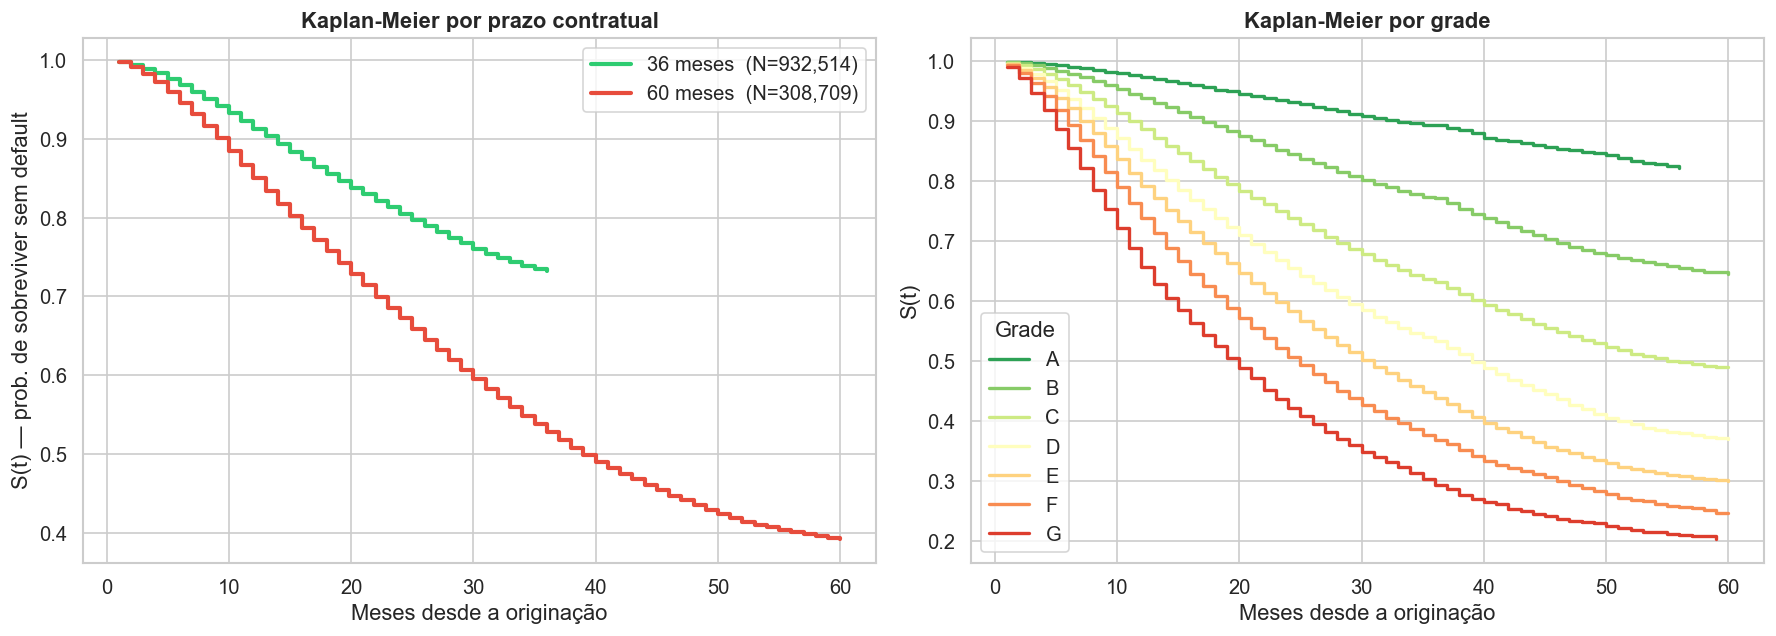

Log-rank 36m × 60m:  chi² = 25335.2  |  p-valor = 0.00e+00


In [29]:
# ── 6.2 Curvas Kaplan-Meier: term e grade ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Painel A — por prazo contratual
for t, c in [(36, '#2ecc71'), (60, '#e74c3c')]:
    sub = df_surv[df_surv['term'] == t]
    sf = SurvfuncRight(sub['duration'], sub['event'])
    axes[0].step(sf.surv_times, sf.surv_prob, where='post',
                 color=c, lw=2.5, label=f'{t} meses  (N={len(sub):,})')
axes[0].set_title('Kaplan-Meier por prazo contratual', fontweight='bold')
axes[0].set_xlabel('Meses desde a originação')
axes[0].set_ylabel('S(t) — prob. de sobreviver sem default')
axes[0].legend()

# Painel B — por grade
for g, c in zip(sorted(df_surv['grade'].dropna().unique()),
                sns.color_palette('RdYlGn_r', 7)):
    sub = df_surv[df_surv['grade'] == g]
    sf = SurvfuncRight(sub['duration'], sub['event'])
    axes[1].step(sf.surv_times, sf.surv_prob, where='post', color=c, lw=2, label=g)
axes[1].set_title('Kaplan-Meier por grade', fontweight='bold')
axes[1].set_xlabel('Meses desde a originação')
axes[1].set_ylabel('S(t)')
axes[1].legend(title='Grade')

plt.tight_layout()
plt.savefig('../assets/19_kaplan_meier.png', bbox_inches='tight')
plt.show()

# Teste log-rank: a sobrevivência difere entre 36 e 60 meses?
chisq, pval = survdiff(df_surv['duration'], df_surv['event'], df_surv['term'])
print(f'Log-rank 36m × 60m:  chi² = {chisq:.1f}  |  p-valor = {pval:.2e}')

### 6.3 — Modelo de Cox (riscos proporcionais)

O modelo de Cox estima o **hazard ratio** de cada fator — o efeito sobre o risco *instantâneo*
de default a cada instante, ajustado pelos demais. É o análogo, em tempo-até-evento, do odds
ratio da Seção 5: `HR > 1` acelera o default; `HR < 1` o retarda. Não exige especificar a
forma do risco de base (semiparamétrico).

In [30]:
# ── 6.3 Modelo de Cox de riscos proporcionais ────────────────
grade_num = {g: i for i, g in enumerate(['A', 'B', 'C', 'D', 'E', 'F', 'G'])}
cox_df = df_surv.copy()
cox_df['grade_num'] = cox_df['grade'].map(grade_num)
cox_df['term60']    = (cox_df['term'] == 60).astype(float)
cox_df['log_inc']   = np.log(cox_df['annual_inc_w'].clip(lower=1))

cox_cols = ['grade_num', 'dti', 'term60', 'log_inc']
cox_df = cox_df.dropna(subset=cox_cols + ['duration', 'event'])

ph_res = PHReg(cox_df['duration'], cox_df[cox_cols],
               status=cox_df['event']).fit()

ci = ph_res.conf_int()
hr = pd.DataFrame({
    'hazard_ratio': np.exp(ph_res.params),
    'ci_low':       np.exp(ci[:, 0]),
    'ci_high':      np.exp(ci[:, 1]),
    'p_value':      ph_res.pvalues,
}, index=cox_cols)

print('=== Hazard ratios — modelo de Cox ===')
print(hr.round(4).to_string())
print('\nLeitura: HR > 1 → acelera o default; HR < 1 → retarda.')
print(f"  term60:    loans de 60 meses têm hazard {hr.loc['term60','hazard_ratio']:.2f}× o de 36m.")
print(f"  grade_num: cada passo de grade (A→B→C…) multiplica o hazard por "
      f"{hr.loc['grade_num','hazard_ratio']:.2f}.")
print(f"  dti:       cada +1 ponto de DTI multiplica o hazard por "
      f"{hr.loc['dti','hazard_ratio']:.3f}.")

=== Hazard ratios — modelo de Cox ===
           hazard_ratio  ci_low  ci_high  p_value
grade_num        1.4386  1.4343   1.4430      0.0
dti              1.0031  1.0029   1.0032      0.0
term60           1.1864  1.1754   1.1976      0.0
log_inc          0.8510  0.8445   0.8576      0.0

Leitura: HR > 1 → acelera o default; HR < 1 → retarda.
  term60:    loans de 60 meses têm hazard 1.19× o de 36m.
  grade_num: cada passo de grade (A→B→C…) multiplica o hazard por 1.44.
  dti:       cada +1 ponto de DTI multiplica o hazard por 1.003.


### 6.4 — Vintage analysis via sobrevivência

O default rate bruto por safra é enganoso: safras de 2017–2018 tiveram menos tempo de
maturação que as de 2011–2012 — comparar as duas diretamente confunde risco com
**truncamento**. A solução de sobrevivência é comparar todas as safras num **horizonte comum**:
a probabilidade de default acumulada até 12, 24 e 36 meses de vida do loan. Aí a comparação é justa.

> **Ressalva importante.** Esta base contém apenas empréstimos com **desfecho resolvido**
> (Fully Paid / Charged Off). Para as safras de 2016–2018 isso introduz **viés de seleção** —
> empréstimos ainda `Current` ficaram de fora, e os defaults precoces resolvem primeiro. A
> comparação por horizonte comum é confiável para as coortes **maduras (≤ 2015)**; ver a
> síntese ao final da seção.


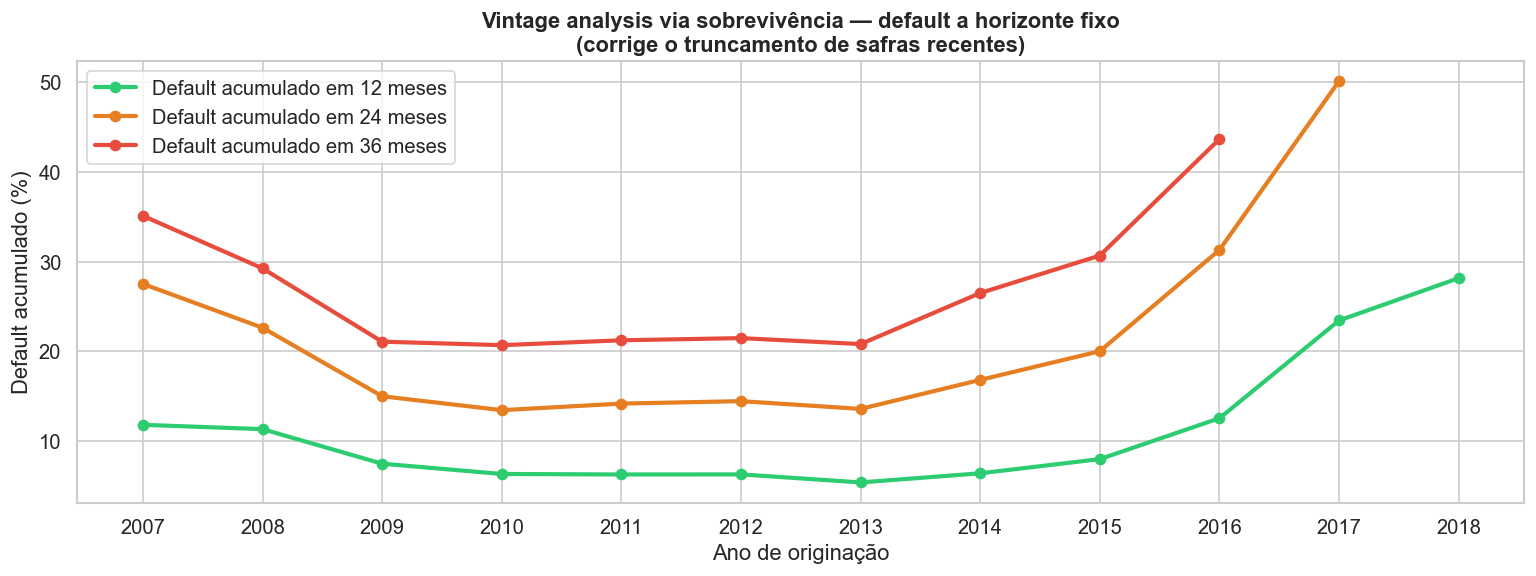

Default acumulado por safra a horizonte fixo (NaN = safra não maturou até o horizonte):
 issue_year      N  default_12m  default_24m  default_36m
       2007    525       0.1177       0.2751       0.3511
       2008   2016       0.1129       0.2261       0.2924
       2009   4397       0.0743       0.1496       0.2106
       2010  10155       0.0628       0.1341       0.2067
       2011  18162       0.0623       0.1414       0.2121
       2012  49510       0.0624       0.1441       0.2145
       2013 127592       0.0534       0.1355       0.2079
       2014 209568       0.0636       0.1679       0.2649
       2015 349454       0.0794       0.1999       0.3067
       2016 270376       0.1250       0.3130       0.4368
       2017 155615       0.2342       0.5015          NaN
       2018  43853       0.2815          NaN          NaN


In [31]:
# ── 6.4 Vintage analysis via sobrevivência (horizonte comum) ──
horizons = [12, 24, 36]
rows = []
for yr in sorted(df_surv['issue_year'].dropna().unique()):
    sub = df_surv[df_surv['issue_year'] == yr]
    if len(sub) < 500:
        continue
    sf = SurvfuncRight(sub['duration'], sub['event'])
    rec = {'issue_year': int(yr), 'N': len(sub)}
    for h in horizons:
        if h > sub['duration'].max():          # safra ainda não maturou até h meses
            rec[f'default_{h}m'] = np.nan
        else:
            idx = np.searchsorted(sf.surv_times, h, side='right') - 1
            rec[f'default_{h}m'] = (1 - sf.surv_prob[idx]) if idx >= 0 else 0.0
    rows.append(rec)
vint_surv = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
for h, c in zip(horizons, ['#2ecc71', '#e67e22', '#e74c3c']):
    ax.plot(vint_surv['issue_year'], vint_surv[f'default_{h}m']*100,
            marker='o', lw=2.5, color=c, label=f'Default acumulado em {h} meses')
ax.set_title('Vintage analysis via sobrevivência — default a horizonte fixo\n'
             '(corrige o truncamento de safras recentes)', fontweight='bold')
ax.set_xlabel('Ano de originação'); ax.set_ylabel('Default acumulado (%)')
ax.legend()
ax.set_xticks(vint_surv['issue_year'].astype(int))
plt.tight_layout()
plt.savefig('../assets/20_vintage_survival.png', bbox_inches='tight')
plt.show()

print('Default acumulado por safra a horizonte fixo (NaN = safra não maturou até o horizonte):')
print(vint_surv.round(4).to_string(index=False))

**Síntese da Seção 6 — o que a sobrevivência revela**

1. **O tempo importa, e o log-rank confirma.** As curvas de 36 e 60 meses são estatisticamente
   distintas (χ² ≈ 25.335, p < 0,001). Empréstimos de 60 meses não só inadimplem mais — fazem-no
   ao longo de uma janela mais longa, risco que a regressão logística binária não enxerga.

2. **O Cox ordena os drivers no tempo.** Cada passo de grade multiplica o hazard de default por
   **1,44**; o prazo de 60 meses, por **1,19**; cada ponto de DTI, por **1,003**; e mais renda
   reduz o hazard (HR 0,85 por unidade de log-renda). As direções confirmam a Seção 5 — agora
   sobre o risco *instantâneo*, não só sobre o desfecho final.

3. **Vintage com cautela — viés de resolução nas safras recentes.** As safras **2007–2015 estão
   maduras** e são confiáveis: o default acumulado em 36 meses sobe de ~21% (2009–2013) para
   **~26–31% (2014–2015)**, confirmando de forma independente a deterioração identificada na
   Seção 4. Já as safras **2016–2018 sofrem viés de seleção**: a base só contém empréstimos que
   já chegaram a um desfecho terminal; os de 2018 ainda `Current` ficaram de fora. Como os
   defaults precoces resolvem primeiro, as coortes recentes super-representam quem quebrou rápido
   — por isso o "default em 12 meses" de 2017–2018 aparece inflado (23–28%) e **não deve ser
   lido como taxa final**.

**Recomendação metodológica:** uma análise de sobrevivência de produção precisa incluir os
empréstimos `Current` como observações **censuradas na data do snapshot**. Com a base restrita
a desfechos resolvidos (definição-alvo do projeto), a leitura de vintage é válida apenas para
coortes maduras (≤ 2015).

---
## Seção 7 — Insight Não-Óbvio: Combinações Tóxicas e Vintage Analysis

A tese central do CREDENCE: **dentro do Grade C, combinações de term 60m + DTI > 20
podem atingir default rates comparáveis ao Grade F.**

Aqui testamos essa hipótese e calculamos o "fator multiplicador de risco" de cada combinação.


In [32]:
# ── 7.1 Combinações tóxicas: Grade C, 60m, DTI alto ─────────
# Classificar DTI em faixas
df['dti_bucket'] = pd.cut(df['dti'], bins=[0,10,20,35,np.inf],
                           labels=['DTI ≤10','DTI 10-20','DTI 20-35','DTI >35'])

toxic = (
    df.groupby(['grade','term','dti_bucket'])['default_flag']
    .agg(['mean','count'])
    .reset_index()
    .rename(columns={'mean':'default_rate','count':'n'})
)
toxic['default_rate_pct'] = toxic['default_rate'] * 100
toxic = toxic[toxic['n'] >= 100]  # N mínimo para confiabilidade

# Grade F como benchmark
grade_f_rate = df[df['grade']=='F']['default_flag'].mean() * 100
grade_c_60_dti20 = toxic[
    (toxic['grade']=='C') & (toxic['term']==60) & (toxic['dti_bucket'].isin(['DTI 20-35','DTI >35']))
]

print(f'Default rate de Grade F (benchmark): {grade_f_rate:.1f}%')
print()
print('=== Grade C + 60 meses + DTI elevado ===')
print(grade_c_60_dti20[['grade','term','dti_bucket','default_rate_pct','n']].to_string(index=False))
print()
print('=== Top 10 combinações com maior inadimplência observada ===')
print(toxic.nlargest(10,'default_rate_pct')[['grade','term','dti_bucket','default_rate_pct','n']].to_string(index=False))


Default rate de Grade F (benchmark): 45.2%

=== Grade C + 60 meses + DTI elevado ===
grade  term dti_bucket  default_rate_pct     n
    C    60  DTI 20-35         30.781387 39865
    C    60    DTI >35         34.768212  2114

=== Top 10 combinações com maior inadimplência observada ===
grade  term dti_bucket  default_rate_pct     n
    G    60    DTI >35         61.718750   384
    F    60    DTI >35         60.347682  1208
    G    36    DTI >35         55.284553   123
    G    60  DTI 20-35         53.151902  3601
    E    60    DTI >35         52.081071  2763
    F    60  DTI 20-35         50.507117 11733
    G    36  DTI 20-35         49.615385   780
    F    36    DTI >35         47.058824   510
    G    60  DTI 10-20         47.049808  2610
    E    60  DTI 20-35         45.761426 26365


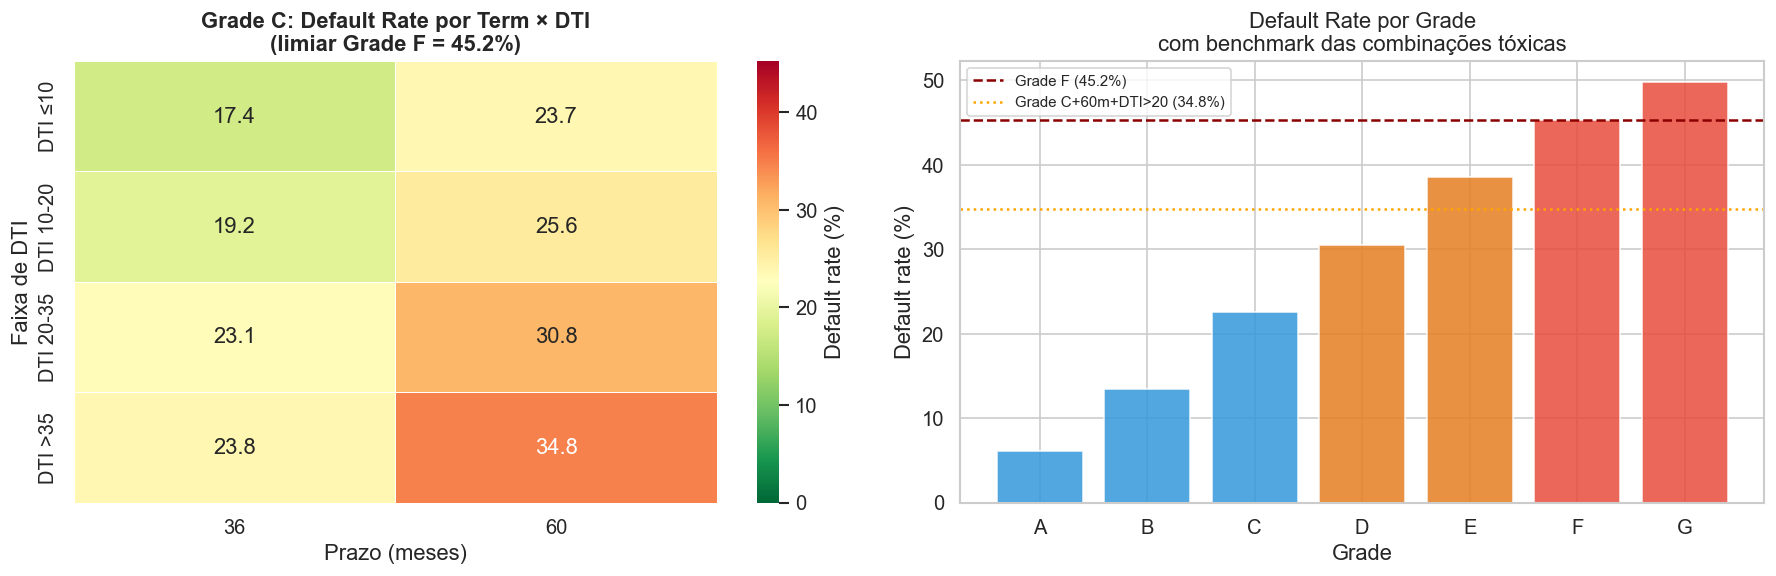

In [33]:
# ── 7.2 Heatmap: Grade C × Term × DTI ───────────────────────
grade_c = toxic[toxic['grade']=='C'].copy()
grade_c_pivot = grade_c.pivot_table(
    index='dti_bucket', columns='term', values='default_rate_pct', aggfunc='mean'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grade C
sns.heatmap(grade_c_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], vmin=0, vmax=grade_f_rate,
            linewidths=0.5, cbar_kws={'label':'Default rate (%)'})
axes[0].set_title(f'Grade C: Default Rate por Term × DTI\n(limiar Grade F = {grade_f_rate:.1f}%)',
                  fontweight='bold')
axes[0].set_xlabel('Prazo (meses)')
axes[0].set_ylabel('Faixa de DTI')

# Comparação Grade C vs Grade F
comp_grades = df.groupby('grade')['default_flag'].agg(['mean','count']).reset_index()
comp_grades['default_rate_pct'] = comp_grades['mean'] * 100
comp_grades['color'] = comp_grades['grade'].apply(
    lambda g: '#e74c3c' if g in ['F','G'] else '#e67e22' if g in ['D','E'] else '#3498db'
)
axes[1].bar(comp_grades['grade'], comp_grades['default_rate_pct'],
            color=comp_grades['color'], alpha=0.85)
axes[1].axhline(grade_f_rate, color='darkred', linestyle='--',
                label=f'Grade F ({grade_f_rate:.1f}%)')

# Marcar Grade C + 60m + DTI >20
worst_c = grade_c_60_dti20['default_rate_pct'].max()
if not np.isnan(worst_c):
    axes[1].axhline(worst_c, color='orange', linestyle=':',
                    label=f'Grade C+60m+DTI>20 ({worst_c:.1f}%)')

axes[1].set_title('Default Rate por Grade\ncom benchmark das combinações tóxicas')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Grade')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../assets/11_combinacoes_toxicas.png', bbox_inches='tight')
plt.show()


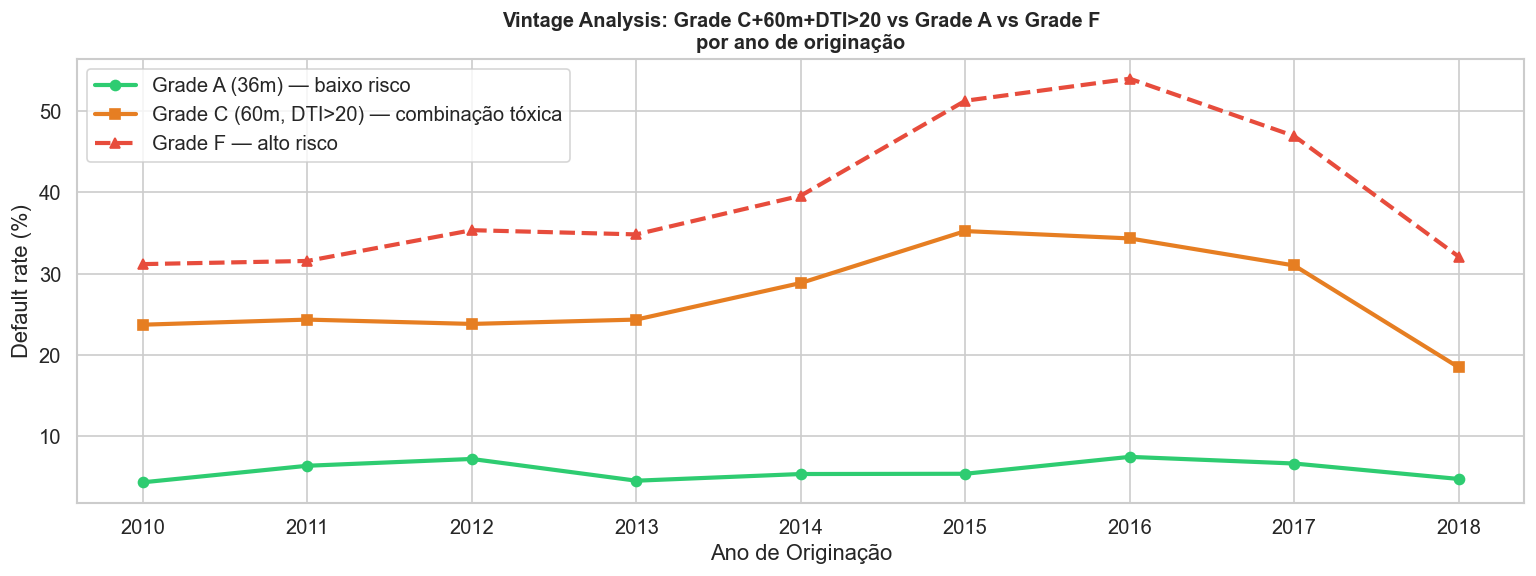

Vintage: comparação de taxas por ano
 issue_year  rate_a36  rate_c60_toxic  rate_f
       2010     0.044           0.237   0.312
       2011     0.064           0.244   0.316
       2012     0.072           0.238   0.354
       2013     0.046           0.244   0.348
       2014     0.054           0.289   0.396
       2015     0.054           0.353   0.513
       2016     0.075           0.343   0.540
       2017     0.067           0.310   0.469
       2018     0.048           0.185   0.321


In [34]:
# ── 7.3 Vintage Analysis ─────────────────────────────────────
# Comparar default rate por ano de originação entre Grade C (60m, DTI>20) vs Grade A

vintage_a = (
    df[(df['grade']=='A') & (df['term']==36)]
    .dropna(subset=['issue_year'])
    .groupby('issue_year')['default_flag']
    .agg(['mean','count'])
    .reset_index()
)
vintage_a.columns = ['issue_year','rate_a36','n_a36']

vintage_c_toxic = (
    df[(df['grade']=='C') & (df['term']==60) & (df['dti'] > 20)]
    .dropna(subset=['issue_year'])
    .groupby('issue_year')['default_flag']
    .agg(['mean','count'])
    .reset_index()
)
vintage_c_toxic.columns = ['issue_year','rate_c60_toxic','n_c60']

vintage = vintage_a.merge(vintage_c_toxic, on='issue_year', how='inner')
vintage_f = (
    df[df['grade']=='F']
    .dropna(subset=['issue_year'])
    .groupby('issue_year')['default_flag']
    .agg(['mean','count'])
    .reset_index()
)
vintage_f.columns = ['issue_year','rate_f','n_f']
vintage = vintage.merge(vintage_f, on='issue_year', how='left')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(vintage['issue_year'], vintage['rate_a36']*100, marker='o',
        color='#2ecc71', linewidth=2.5, label='Grade A (36m) — baixo risco')
ax.plot(vintage['issue_year'], vintage['rate_c60_toxic']*100, marker='s',
        color='#e67e22', linewidth=2.5, label='Grade C (60m, DTI>20) — combinação tóxica')
ax.plot(vintage['issue_year'], vintage['rate_f']*100, marker='^',
        color='#e74c3c', linewidth=2.5, linestyle='--', label='Grade F — alto risco')

ax.set_title('Vintage Analysis: Grade C+60m+DTI>20 vs Grade A vs Grade F\n'
             'por ano de originação', fontweight='bold', fontsize=12)
ax.set_ylabel('Default rate (%)')
ax.set_xlabel('Ano de Originação')
ax.legend()
ax.set_xticks(vintage['issue_year'].astype(int))
plt.tight_layout()
plt.savefig('../assets/12_vintage_analysis.png', bbox_inches='tight')
plt.show()

print('Vintage: comparação de taxas por ano')
print(vintage[['issue_year','rate_a36','rate_c60_toxic','rate_f']].round(3).to_string(index=False))


---
## Seção 7.4 — Combinação Tóxica Multi-Dimensional + Simulação Direcional de P&L

A Seção 7 mostrou combinações de alto default (grade × term × DTI). Esta seção responde à
pergunta de negócio: **quais combinações aparecem como candidatas a corte ou reprecificação?**

A resposta exige distinguir dois conceitos que costumam ser confundidos:

- **Alto default rate** — a combinação tem muita inadimplência.
- **Destruição de valor** — a combinação dá prejuízo *depois* de descontar a receita de juros.

São coisas diferentes: uma combinação com 60% de default pode aparecer **rentável** na simulação se cobrar
29% de juros. Esta seção é uma **simulação direcional de rentabilidade risco-ajustada** para comparar segmentos, não uma apuração de lucro real da carteira. O sinal mais útil para política de crédito é o **P&L risco-ajustado estimado**, não o
default rate isolado.

Adicionamos um quarto fator à análise — **geografia (`geo_tier`)** da Seção 2.7. Verificação
de renda foi excluída (variável endógena — ver Seção 2.8). A combinação é de **4 dimensões**.

### Simulação direcional de P&L por empréstimo (premissas documentadas)

| Parâmetro | Valor | Racional |
|-----------|-------|----------|
| LGD | 60% | Padrão Basileia para *unsecured retail* (literatura empírica 55–65%) |
| Custo de funding | 4% a.a. | Proxy do *cost of capital* de fintech P2P 2014–2018 |
| Duration | `term / 24` anos | Duration média ≈ metade do prazo (amortização linear) |
| **Fração de juros coletada em loans inadimplentes** | **50%** | Um loan que vira charge-off **para de pagar no meio do caminho** — coletou ~metade dos juros agendados antes do default. Sem esse ajuste, o modelo daria receita cheia a loans inadimplentes e **superestimaria a lucratividade dos segmentos de alto risco**. |

```
receita(loan)  = valor × spread_líquido × duration × (1 se adimplente; 0,5 se inadimplente)
perda(loan)    = valor × LGD × inadimplente
pnl_líquido    = receita − perda
```

> As premissas servem para *ranking relativo* — qual combinação aparece com P&L negativo na simulação — não para
> projeção absoluta de P&L nem para apuração de lucro real da carteira. Em produção, LGD, curva de recuperação, pré-pagamento, servicing, impostos, custos operacionais e custo de funding viriam de modelos próprios / ALM.


In [35]:
# ── 7.4.1 Construir geo_tier ────────────────────────────────
# geo_tier baseado no residual geográfico da Seção 2.7
q_high = geo_decomp['pure_geo_effect_pp'].quantile(0.75)
q_low  = geo_decomp['pure_geo_effect_pp'].quantile(0.25)

def classify_geo(eff):
    if pd.isna(eff): return 'UNKNOWN'
    if eff >= q_high: return 'HIGH'
    if eff <= q_low:  return 'LOW'
    return 'MED'

geo_decomp['geo_tier'] = geo_decomp['pure_geo_effect_pp'].apply(classify_geo)
state_to_tier = dict(zip(geo_decomp['addr_state'], geo_decomp['geo_tier']))
df['geo_tier'] = df['addr_state'].map(state_to_tier).fillna('UNKNOWN')

# verification_status NÃO entra como feature de risco — é endógena (ver Seção 2.8).
# Mantida apenas como coluna descritiva no export do Looker (Seção 9).

print('Distribuição geo_tier:')
print(df['geo_tier'].value_counts())
print(f'\nThresholds geo_tier (residual geográfico p.p.):  HIGH ≥ {q_high:.2f}  |  LOW ≤ {q_low:.2f}')
print('\nDefault rate por geo_tier:')
print((df.groupby('geo_tier')['default_flag'].mean()*100).round(2).to_string())


Distribuição geo_tier:
geo_tier
MED        793841
HIGH       377576
LOW        134956
UNKNOWN        14
Name: count, dtype: int64

Thresholds geo_tier (residual geográfico p.p.):  HIGH ≥ 1.09  |  LOW ≤ -2.45

Default rate por geo_tier:
geo_tier
HIGH       22.14
LOW        15.76
MED        19.85
UNKNOWN    21.43


In [36]:
# ── 7.4.2 Combinação de 4 dimensões: default rate × P&L risco-ajustado ──
LGD                = 0.60   # Loss Given Default
COST_OF_FUNDS      = 0.04   # custo de funding a.a.
FRAC_JUROS_DEFAULT = 0.50   # fração dos juros coletada antes do charge-off

# Simulação direcional de P&L risco-ajustado por loan
df['_dur']  = df['term'].astype(float) / 24.0
df['_spr']  = (df['int_rate']/100.0 - COST_OF_FUNDS).clip(lower=0)
df['_rev']  = (df['loan_amnt'] * df['_spr'] * df['_dur']
               * np.where(df['default_flag']==1, FRAC_JUROS_DEFAULT, 1.0))
df['_loss'] = df['loan_amnt'] * df['default_flag'] * LGD
df['_net']  = df['_rev'] - df['_loss']

combo = (
    df.groupby(['grade','term','dti_bucket','geo_tier'], observed=True)
      .agg(n=('default_flag','count'),
           default_rate=('default_flag','mean'),
           avg_int_rate=('int_rate','mean'),
           total_volume=('loan_amnt','sum'),
           net_pnl=('_net','sum'))
      .reset_index()
)
combo['default_rate_pct'] = combo['default_rate'] * 100
combo['net_pnl_por_loan'] = combo['net_pnl'] / combo['n']
combo = combo[combo['n'] >= 100].copy()  # piso de confiabilidade

print('=== As 10 combinações de MAIOR default rate ===')
print('(juros de 25-29% compensam o risco — a maioria NÃO destrói valor)')
print(combo.nlargest(10,'default_rate_pct')[
    ['grade','term','dti_bucket','geo_tier','n','default_rate_pct','avg_int_rate','net_pnl_por_loan']
].round(1).to_string(index=False))

print('\n=== As 10 combinações com menor P&L estimado por loan ===')
print('(default moderado, mas mal precificado na simulação — sinal para revisão)')
print(combo.nsmallest(10,'net_pnl_por_loan')[
    ['grade','term','dti_bucket','geo_tier','n','default_rate_pct','avg_int_rate','net_pnl_por_loan']
].round(1).to_string(index=False))


=== As 10 combinações de MAIOR default rate ===
(juros de 25-29% compensam o risco — a maioria NÃO destrói valor)
grade  term dti_bucket geo_tier    n  default_rate_pct  avg_int_rate  net_pnl_por_loan
    G    60    DTI >35     HIGH  107              70.1          29.2            -337.2
    F    60    DTI >35      MED  732              61.7          25.1            -174.2
    G    60    DTI >35      MED  226              61.1          28.9            1847.8
    F    60    DTI >35     HIGH  343              60.3          25.2             277.4
    G    60  DTI 20-35     HIGH 1065              56.5          27.9            1845.3
    E    60    DTI >35     HIGH  818              54.2          20.7            -147.8
    G    36  DTI 20-35      MED  449              53.9          27.4            -774.8
    E    60    DTI >35      MED 1631              53.3          20.6            -183.2
    G    60  DTI 20-35      MED 2180              53.2          27.8            2652.1
    F    60    D

In [37]:
# ── 7.4.3 Duas estratégias de corte: ingênua vs risco-ajustada ──
total_pnl = combo['net_pnl'].sum()
total_n   = combo['n'].sum()
total_vol = combo['total_volume'].sum()

# Estratégia A (ingênua): cortar as 15 combinações de MAIOR default rate
naive = combo.nlargest(15, 'default_rate_pct')
pnl_a = naive['net_pnl'].sum()

# Estratégia B (risco-ajustada): cortar as combinações com P&L líquido < 0
neg = combo[combo['net_pnl'] < 0]
pnl_b = neg['net_pnl'].sum()

print('=== ESTRATÉGIA A — cortar as 15 de maior default rate (INGÊNUA) ===')
print(f'  Combinações: 15  |  N de loans: {naive["n"].sum():,}')
print(f'  P&L dessas combinações: ${pnl_a/1e6:+.1f} M')
print(f'  → Efeito estimado de cortá-las: ${-pnl_a/1e6:+.1f} M')
if pnl_a > 0:
    print('  ✗ Essas combinações são LUCRATIVAS — cortá-las DESTRÓI valor.')
    print('    Default alto, mas os juros de 25-29% mais que compensam o risco.')

print('\n=== ESTRATÉGIA B — cortar combinações com P&L negativo (RISCO-AJUSTADA) ===')
print(f'  Combinações: {len(neg)}  |  N de loans: {neg["n"].sum():,} '
      f'({neg["n"].sum()/total_n*100:.1f}% da carteira)')
print(f'  Volume: ${neg["total_volume"].sum()/1e9:.2f} B')
print(f'  → Ganho líquido ao cortar: ${-pnl_b/1e6:+.1f} M')

# Efeito estimado na default rate da carteira
keys_b = set(map(tuple, neg[['grade','term','dti_bucket','geo_tier']].values))
df['_k'] = list(zip(df['grade'], df['term'], df['dti_bucket'], df['geo_tier']))
dr_pre = df['default_flag'].mean()*100
dr_pos = df[~df['_k'].isin(keys_b)]['default_flag'].mean()*100
print(f'  Default rate da carteira: {dr_pre:.2f}% → {dr_pos:.2f}%  ({(dr_pre-dr_pos)*100:.0f} bps)')

# Onde está a destruição de valor — composição por grade
print('\n=== Onde está a destruição de valor (combos P&L<0, por grade) ===')
print(neg.groupby('grade').agg(n_combos=('n','size'), n_loans=('n','sum')).to_string())
print('\n→ A destruição NÃO está nos Grades F/G (cauda extrema, bem precificada),')
print('  e sim no MEIO mal precificado: 36 meses, DTI 20-35, geografia de risco.')


=== ESTRATÉGIA A — cortar as 15 de maior default rate (INGÊNUA) ===
  Combinações: 15  |  N de loans: 26,685
  P&L dessas combinações: $+33.1 M
  → Efeito estimado de cortá-las: $-33.1 M
  ✗ Essas combinações são LUCRATIVAS — cortá-las DESTRÓI valor.
    Default alto, mas os juros de 25-29% mais que compensam o risco.

=== ESTRATÉGIA B — cortar combinações com P&L negativo (RISCO-AJUSTADA) ===
  Combinações: 32  |  N de loans: 251,825 (19.3% da carteira)
  Volume: $3.14 B
  → Ganho líquido ao cortar: $+36.8 M
  Default rate da carteira: 20.09% → 18.87%  (122 bps)

=== Onde está a destruição de valor (combos P&L<0, por grade) ===
       n_combos  n_loans
grade                   
A             3    17446
B             2    34388
C             5   105114
D             6    67596
E             7    22312
F             5     4042
G             4      927

→ A destruição NÃO está nos Grades F/G (cauda extrema, bem precificada),
  e sim no MEIO mal precificado: 36 meses, DTI 20-35, geografia 

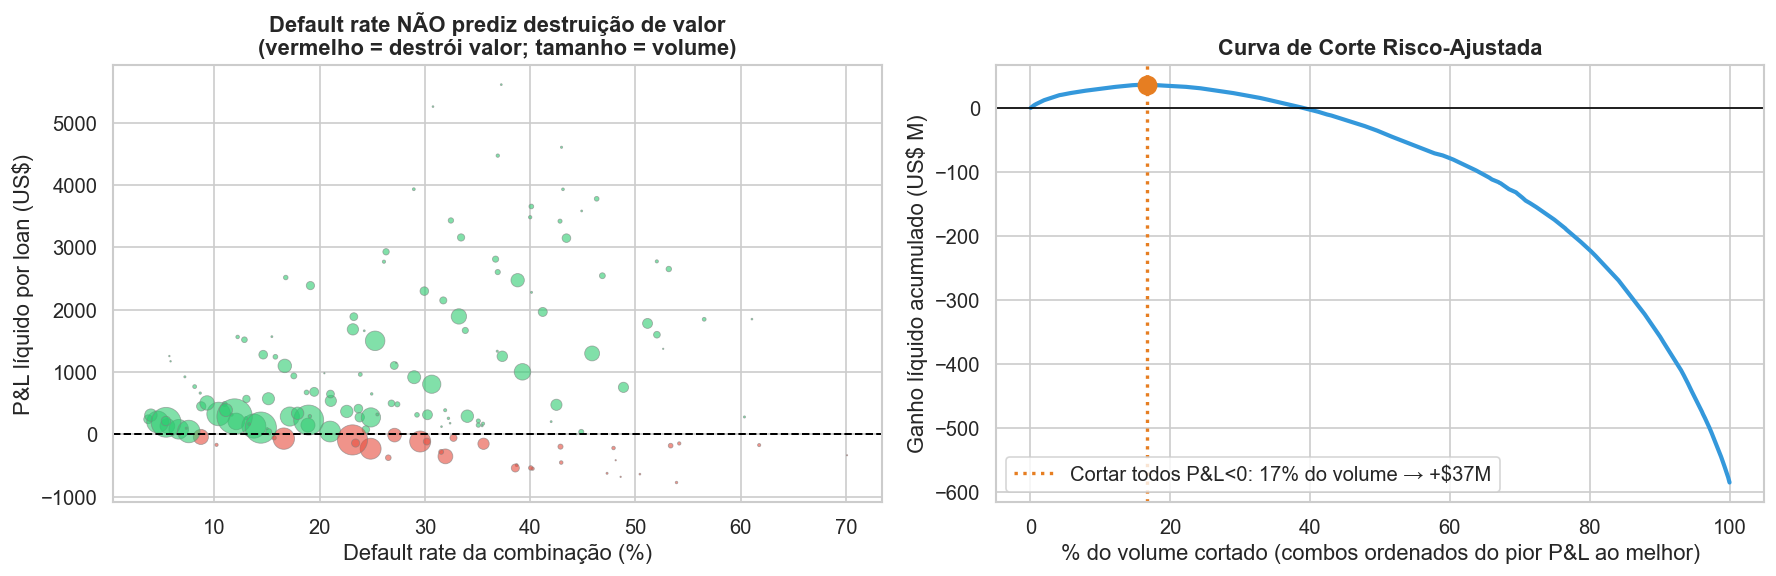

→ PONTO ÓTIMO: cortar/reprecificar as 32 combinações com P&L negativo
  16.7% do volume da carteira  →  ganho líquido de $+37 M
  Cortar além disso passa a destruir valor (combos lucrativos).


In [38]:
# ── 7.4.4 Curva de corte risco-ajustada ─────────────────────
# Ordena combinações do PIOR P&L por loan ao melhor
combo_ord = combo.sort_values('net_pnl_por_loan').reset_index(drop=True)
combo_ord['ganho_acum']   = (-combo_ord['net_pnl']).cumsum()      # ganho ao cortar até aqui
combo_ord['vol_acum_pct'] = combo_ord['total_volume'].cumsum() / total_vol * 100
n_neg = int((combo['net_pnl'] < 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) default rate NÃO prediz destruição de valor
cores = ['#e74c3c' if x < 0 else '#2ecc71' for x in combo['net_pnl']]
axes[0].scatter(combo['default_rate_pct'], combo['net_pnl_por_loan'],
                s=combo['n']/200, c=cores, alpha=0.6, edgecolors='gray', linewidths=0.5)
axes[0].axhline(0, color='black', lw=1.2, ls='--')
axes[0].set_xlabel('Default rate da combinação (%)')
axes[0].set_ylabel('P&L líquido por loan (US$)')
axes[0].set_title('Default rate NÃO prediz destruição de valor\n'
                  '(vermelho = destrói valor; tamanho = volume)', fontweight='bold')

# (b) curva de ganho acumulado ao cortar do pior P&L ao melhor
axes[1].plot(combo_ord['vol_acum_pct'], combo_ord['ganho_acum']/1e6,
             color='#3498db', linewidth=2.5)
axes[1].axhline(0, color='black', lw=1)
pico_vol = combo_ord['vol_acum_pct'].iloc[n_neg-1]
pico_val = combo_ord['ganho_acum'].iloc[n_neg-1]/1e6
axes[1].axvline(pico_vol, color='#e67e22', linestyle=':', linewidth=2,
                label=f'Cortar todos P&L<0: {pico_vol:.0f}% do volume → +${pico_val:.0f}M')
axes[1].scatter([pico_vol], [pico_val], color='#e67e22', s=120, zorder=5)
axes[1].set_xlabel('% do volume cortado (combos ordenados do pior P&L ao melhor)')
axes[1].set_ylabel('Ganho líquido acumulado (US$ M)')
axes[1].set_title('Curva de Corte Risco-Ajustada', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/15_pnl_tradeoff.png', bbox_inches='tight')
plt.show()

print(f'→ PONTO ÓTIMO: cortar/reprecificar as {n_neg} combinações com P&L negativo')
print(f'  {pico_vol:.1f}% do volume da carteira  →  ganho líquido de ${pico_val:+.0f} M')
print(f'  Cortar além disso passa a destruir valor (combos lucrativos).')


---
## Seção 8 — Recomendações para Política de Crédito


---

### O que os dados mostram

1. **O grade sozinho não conta a história completa.** Um cliente Grade C que pede 60 meses
   e tem DTI acima de 20 apresenta inadimplência de ~31% — 1,4× a média do seu próprio grade,
   no nível de um Grade D/E. A política atual, ao classificá-lo como "risco médio", pode tratar
   esse segmento como menos arriscado do que os dados sugerem.

2. **Empréstimos de 60 meses aparecem sistematicamente associados a maior risco** — em todos os grades,
   o prazo longo está associado a quase o dobro da taxa de inadimplência em relação ao prazo de 36 meses.
   O mercado precifica parte disso via taxa de juros mais alta, mas não o suficiente.

3. **DTI aparece como um sinal de risco subprecificado.** Acima de 35, a taxa de inadimplência aumenta de forma acentuada mesmo após segmentar
   por grade. Clientes com renda alta mas dívidas altas apresentam risco comparável ao de clientes
   de baixa renda sem dívidas.

4. **`small_business` e `renewable_energy` têm os maiores default rates por purpose.**
   Empréstimos pessoais usados como capital de giro são tratados pelo modelo de score
   como crédito de consumo — sinal de possível desalinhamento de classificação de risco.

5. **O crescimento da inadimplência entre 2009 e 2012 é compatível predominantemente com efeito de mix**
   (mais empréstimos de Grades D+E sendo aprovados), não deterioração dentro dos grades.
   A partir de 2013, o efeito se inverte: o volume de D+E estabilizou, mas a taxa dentro
   do segmento aumentou — sinal compatível com deterioração dos critérios de aprovação.

6. **Geografia aparece associada a risco residual mesmo controlando por mix de grade.** A decomposição
   Oaxaca-Blinder da Seção 2.7 identifica estados com *excesso de default* residual após composição
   pela composição da carteira local — fatores macro regionais que o score atual pode não captar.

7. **A verificação de renda NÃO é um sinal de proteção — é uma variável endógena.** A Seção 2.8
   mostrou que loans `Not Verified` têm *menor* inadimplência em todas as faixas de renda,
   porque o Lending Club verificava justamente os pedidos que já pareciam suspeitos.
   `verification_status` reflete uma triagem de risco anterior do LC, não uma causa — e por
   isso não pode embasar política de crédito.

8. **Default rate alto NÃO é o mesmo que P&L estimado negativo.** A Seção 7.4, como simulação direcional de rentabilidade
   risco-ajustada, sugere que as combinações de *maior* inadimplência (Grades F/G, 60m, DTI
   alto — 50-70% de default) aparecem **rentáveis na simulação**: os juros de 25-29% compensam o risco.
   O P&L negativo estimado na simulação aparece no **meio mal precificado** — combinações de 36 meses,
   DTI 20-35 e geografia de risco, nos Grades A-E, que defaultam 8-39% mas são precificadas
   para o grade, sem capturar o DTI nem a geografia. Reprecificar essas ~32 combinações
   está associado a ~+$37M de P&L estimado e ~120 bps a menos na inadimplência da carteira no cenário simulado.

9. **O modelo de risco rankeia bem, mas se descalibra fora do tempo.** Treinado em 2007–2015 e
   testado em 2016–2018, o AUC cai pouco (0,71 → 0,68), mas o modelo **subestima o default
   observado em 3–7 p.p.** em toda a faixa de score (Seção 5.5). O regime de risco piorou — a
   inadimplência subiu de 18,5% para 22,9% entre os dois períodos.

10. **As alavancas acionáveis de underwriting são term e DTI.** Os efeitos marginais (Seção 5.6)
    mostram que o prazo de 60 meses adiciona +6,7 p.p. de probabilidade de default e cada 10 p.p.
    de DTI, +1,7 p.p. — controlando grade, purpose e renda. Grade pesa mais em magnitude, mas é
    atribuído; term e DTI são negociáveis no ato da aprovação.

11. **O risco é tempo-dependente: 60 meses inadimple mais e por mais tempo.** A análise de
    sobrevivência (Seção 6) confirma, via log-rank e modelo de Cox, que o prazo longo acelera o
    hazard de default. O vintage por horizonte comum reproduz a deterioração das safras
    2014–2015, mas as safras 2016–2018 sofrem viés de resolução e não devem ser lidas como taxa
    final.

---

### Recomendações

| # | Prioridade | Ação | Segmento-alvo | Efeito estimado |
|---|------------|------|---------------|------------------|
| 1 | **Alta** | Criar teto de DTI de 30 para empréstimos de 60 meses em Grades C, D e E | Grades C–E, term 60m | Reduzir ~8–12 p.p. de default rate no segmento |
| 2 | **Alta** | **Repricing das combinações com P&L risco-ajustado estimado negativo** (Seção 7.4) — ~32 combinações `36m + DTI 20-35 + geo HIGH/MED` nos Grades A-E. Adicionar bps ou restringir | ~19% da carteira | +$37M de P&L; inadimplência −120 bps |
| 3 | **Alta** | Exigir verificação de renda obrigatória para `small_business` e `renewable_energy` | Todos os grades | Reduzir exposição a purpose de alto risco |
| 4 | **Alta** | **Cap de exposição por estado de alto risco** (top 25% de efeito geográfico residual) — máximo 8% da carteira por estado-tier `HIGH` | Estados em `geo_tier=HIGH` | Reduzir concentração regional sem violar ECOA |
| 5 | **Média** | Repricing automático: adicionar 150–200 bps para combinação Grade C + 60m + DTI>20 | Grade C, term 60m | Compensar o risco não precificado ou desincentivar a demanda |
| 6 | **Média** | Limitar participação de Grades D+E a no máximo 25% do volume trimestral | Grades D e E | Controlar efeito de mix antes que escale |
| 7 | **Baixa** | Dashboard de vintage: monitorar default rate por coorte de originação | Todos | Early warning de deterioração antes de aparecer no P&L |
| 8 | **Média** | **Recalibrar o modelo de risco** antes de uso em provisão/pricing e monitorar **calibração por safra** (não só AUC) | Modelo de crédito | Evita subprovisionamento da carteira recente (Seção 5.5) |

---

### Considerações regulatórias (Fair Lending — ECOA / Reg B)

As recomendações 2 e 4 envolvem `addr_state` e devem respeitar regras de *fair lending*:

- **Permitido:** *risk-based pricing* documentado, *caps de exposição* atuarialmente justificados,
  monitoramento de concentração geográfica.
- **Proibido:** *underwriting cutoff* individual baseado apenas em estado/região (caracteriza
  *disparate impact*), variáveis proxy de raça/etnia.
- **Documentação necessária:** *Annual Fair Lending Risk Assessment* mostrando que o cap por
  estado é matematicamente derivado do residual geográfico de default e revisado anualmente.

---

### O que NÃO fazer

- **Não cortar combinações só porque têm default rate alto.** Se o juro cobrado compensa o
  risco (caso das combinações F/G a 25-29%), cortá-las **destrói valor**. A decisão de corte
  deve ser pelo P&L risco-ajustado, não pelo default rate isolado.

- **Não cortar o crédito para Grade C indiscriminadamente.** A maioria dos Grade C com 36 meses
  e DTI < 20 tem performance comparável ao Grade B. Um corte amplo sacrifica volume sem ganho
  proporcional de risco.

- **Não usar apenas a taxa de juros como proxy de precificação de risco.** Os dados mostram que
  a taxa atual não captura adequadamente o risco incremental de prazo longo + DTI alto.

- **Não usar `addr_state` como cutoff individual de aprovação.** Isso violaria ECOA. Use como
  *pricing factor* e *concentration cap*, com documentação atuarial anual.

- **Não interpretar `verification_status` como medida de qualidade do borrower.** É uma variável
  endógena: loans verificados aparecem com mais inadimplência apenas porque o LC já os havia
  sinalizado como suspeitos.


In [39]:
# ── 8.1 Painel resumo: combinações tóxicas vs seguras ────────
summary = (
    df.groupby(['grade','term'])['default_flag']
    .agg(['mean','count'])
    .reset_index()
)
summary.columns = ['grade','term','default_rate','n']
summary['default_rate_pct'] = summary['default_rate'] * 100
summary['risk_label'] = summary['default_rate_pct'].apply(
    lambda r: '🔴 Alto' if r >= 25 else '🟡 Médio' if r >= 15 else '🟢 Baixo'
)

pivot_summary = summary.pivot_table(
    index='grade', columns='term', values='default_rate_pct', aggfunc='mean'
).round(1)

print('=== Default Rate (%) por Grade × Prazo — Mapa de Risco ===')
print(pivot_summary.to_string())
print(f'\nBenchmark Grade F: {grade_f_rate:.1f}%')
print(f'Média geral:        {df["default_flag"].mean()*100:.1f}%')


=== Default Rate (%) por Grade × Prazo — Mapa de Risco ===
term     36    60
grade            
A       6.0  10.5
B      12.8  18.1
C      20.6  27.5
D      27.0  36.3
E      32.8  42.2
F      38.3  47.3
G      47.0  50.4

Benchmark Grade F: 45.2%
Média geral:        20.1%


In [40]:
# ── 8.2 Resumo final: tese central confirmada? ───────────────
worst_c60 = df[(df['grade']=='C') & (df['term']==60) & (df['dti']>20)]['default_flag'].mean() * 100
grade_f_rate_full = df[df['grade']=='F']['default_flag'].mean() * 100
grade_c_all = df[df['grade']=='C']['default_flag'].mean() * 100

print('=== TESE CENTRAL DO CREDENCE ===')
print(f'Grade C (geral):                    {grade_c_all:.1f}%')
print(f'Grade C + 60m + DTI>20:             {worst_c60:.1f}%')
print(f'Grade F (benchmark):                {grade_f_rate_full:.1f}%')
print()
if worst_c60 >= grade_f_rate_full * 0.85:
    print('✓ CONFIRMADA: Grade C+60m+DTI>20 atinge ou supera o nível de risco do Grade F.')
    print('  O grade é, de fato, um proxy IMPERFEITO de risco.')
else:
    diff_to_f = grade_f_rate_full - worst_c60
    print(f'~ PARCIALMENTE CONFIRMADA: Grade C+60m+DTI>20 está {diff_to_f:.1f} p.p. abaixo do Grade F.')
    print(f'  Mas representa {worst_c60/grade_c_all:.1f}x o risco de um Grade C médio.')
    print('  O grade ainda é proxy imperfeito — a combinação tóxica é significativamente pior.')


=== TESE CENTRAL DO CREDENCE ===
Grade C (geral):                    22.5%
Grade C + 60m + DTI>20:             31.0%
Grade F (benchmark):                45.2%

~ PARCIALMENTE CONFIRMADA: Grade C+60m+DTI>20 está 14.3 p.p. abaixo do Grade F.
  Mas representa 1.4x o risco de um Grade C médio.
  O grade ainda é proxy imperfeito — a combinação tóxica é significativamente pior.


---
## Seção 9 — Exportação para o Looker Studio

Gera `exports/looker_ready.csv` — a base do dashboard (Parte 1 do CREDENCE).

**Decisões de exportação:**

1. **Inclui `Late (31-120 days)`** além de Fully Paid / Charged Off / Default. Esses registros
   ficam de fora da análise principal, mas são necessários para o **parâmetro self-service**
   do Looker que alterna entre a definição estrita de inadimplência e a alternativa
   (Late 31-120 incluído). Por isso o CSV traz duas colunas: `default_flag` (estrita) e
   `default_flag_alt` (inclui Late 31-120).

2. **Todas as colunas derivadas** das Seções 2.7/2.8/7.4 vão no CSV (`grade_group`,
   `dti_bucket`, `income_bucket`, `geo_tier`, `verif_tier`). `verif_tier` entra apenas como
   coluna **descritiva** — não é feature de risco (ver Seção 2.8: variável endógena).

3. **Amostragem por tamanho de arquivo.** O Looker Studio limita uploads de CSV a ~100 MB.
   O alvo é **500.000 linhas** (~80 MB). Se a base ultrapassar esse número, aplica-se
   **amostra estratificada por `grade × default_flag`** — a estratificação proporcional
   preserva o tamanho *relativo* de cada segmento, então um segmento pequeno continua
   pequeno no dashboard, atendendo à regra do CLAUDE.md de exibir "Taxa: X% (N=Y)" sem
   induzir interpretação enganosa de segmentos minúsculos.


In [41]:
# ── 9.1 Montar base de exportação para o Looker ─────
import os
os.makedirs('../exports', exist_ok=True)

# Inclui Late (31-120 days) para a definição alternativa self-service
STATUS_LOOKER = STATUS_PAID + STATUS_DEFAULT + ['Late (31-120 days)']
df_looker = df_raw[df_raw['loan_status'].isin(STATUS_LOOKER)].copy()

# Reaplica os tratamentos padrão (df_raw não os tem)
df_looker['int_rate'] = pd.to_numeric(
    df_looker['int_rate'].astype(str).str.replace('%', '').str.strip(), errors='coerce')
df_looker['term'] = df_looker['term'].astype(str).str.extract(r'(\d+)').astype(float).astype('Int64')
df_looker['emp_length'] = df_looker['emp_length'].apply(parse_emp_length)
df_looker['issue_d'] = pd.to_datetime(df_looker['issue_d'], format='%b-%Y', errors='coerce')
df_looker['issue_year']  = df_looker['issue_d'].dt.year.astype('Int64')
df_looker['issue_month'] = df_looker['issue_d'].dt.month.astype('Int64')

# Duas definições de inadimplência (parâmetro self-service no Looker)
df_looker['default_flag']     = df_looker['loan_status'].isin(STATUS_DEFAULT).astype(int)
df_looker['default_flag_alt'] = df_looker['loan_status'].isin(
    STATUS_DEFAULT + ['Late (31-120 days)']).astype(int)

# Colunas derivadas (Seções 2–6)
df_looker['annual_inc_w']  = df_looker['annual_inc'].clip(upper=P99_INC)
df_looker['grade_group']   = df_looker['grade'].apply(lambda g: 'D+E' if g in ['D','E'] else 'Demais')
df_looker['dti_bucket']    = pd.cut(df_looker['dti'], bins=[0,10,20,35,np.inf],
                                    labels=['DTI ≤10','DTI 10-20','DTI 20-35','DTI >35'])
df_looker['income_bucket'] = pd.cut(df_looker['annual_inc'],
                                    bins=[0,40_000,60_000,100_000,150_000,np.inf],
                                    labels=['<$40k','$40k-60k','$60k-100k','$100k-150k','>$150k'])
df_looker['geo_tier']      = df_looker['addr_state'].map(state_to_tier).fillna('UNKNOWN')
df_looker['verif_tier']    = df_looker['verification_status'].map(
    {'Verified':'VERIFIED','Source Verified':'VERIFIED','Not Verified':'NOT_VERIFIED'}).fillna('UNKNOWN')

COLS_LOOKER = ['loan_amnt','term','int_rate','installment','grade','sub_grade',
    'emp_length','home_ownership','annual_inc','annual_inc_w','verification_status',
    'loan_status','purpose','addr_state','dti','revol_util','total_acc',
    'issue_year','issue_month','default_flag','default_flag_alt',
    'grade_group','dti_bucket','income_bucket','geo_tier','verif_tier']
export = df_looker[COLS_LOOKER].copy()
print(f'Base de exportação: {len(export):,} linhas × {export.shape[1]} colunas')
print(f'  Fully Paid / Charged Off / Default: {(export["loan_status"] != "Late (31-120 days)").sum():,}')
print(f'  Late (31-120 days) [só p/ def. alternativa]: {(export["loan_status"] == "Late (31-120 days)").sum():,}')


Base de exportação: 1,328,284 linhas × 26 colunas
  Fully Paid / Charged Off / Default: 1,306,387
  Late (31-120 days) [só p/ def. alternativa]: 21,897


In [42]:
# ── 9.2 Amostragem (se necessário) e gravação do CSV ──────
# Looker Studio limita uploads a ~100 MB → alvo de 500k linhas (~80 MB)
LIMITE_LOOKER = 500_000

if len(export) <= LIMITE_LOOKER:
    export_final = export
    modo = 'completo'
else:
    frac = LIMITE_LOOKER / len(export)
    export_final = export.groupby(['grade','default_flag'], group_keys=False).sample(
        frac=frac, random_state=SEED)
    modo = f'amostra estratificada por grade × default_flag (frac={frac:.3f})'

caminho = '../exports/looker_ready.csv'
export_final.to_csv(caminho, index=False)
tamanho_mb = os.path.getsize(caminho) / 1e6
print(f'✓ CSV gravado: {caminho}')
print(f'  Modo: {modo}')
print(f'  {len(export_final):,} linhas | {tamanho_mb:.1f} MB')

# Verificação: taxas na amostra vs população (devem ser próximas)
print('\n=== Verificação amostra vs população (default_flag) ===')
verif = pd.DataFrame({
    'pop_default_rate': export.groupby('grade')['default_flag'].mean()*100,
    'amostra_default_rate': export_final.groupby('grade')['default_flag'].mean()*100,
    'pop_N': export.groupby('grade').size(),
    'amostra_N': export_final.groupby('grade').size(),
})
print(verif.round(2).to_string())

# Painel de referência: N absoluto da POPULAÇÃO por segmento-chave
print('\n=== N absoluto (população) — referência para o dashboard ===')
print('Regra CLAUDE.md: toda taxa no Looker deve exibir "X% (N = Y)".')
ref = export.groupby('grade_group').agg(
    N=('default_flag','size'), default_rate_pct=('default_flag','mean'))
ref['default_rate_pct'] = (ref['default_rate_pct']*100).round(2)
print(ref.to_string())


✓ CSV gravado: ../exports/looker_ready.csv
  Modo: amostra estratificada por grade × default_flag (frac=0.376)
  500,001 linhas | 81.8 MB

=== Verificação amostra vs população (default_flag) ===
       pop_default_rate  amostra_default_rate   pop_N  amostra_N
grade                                                           
A                  6.05                  6.05  227657      85696
B                 13.28                 13.28  385270     145026
C                 22.06                 22.06  378206     142366
D                 29.68                 29.68  200964      75648
E                 37.66                 37.66   94336      35511
F                 44.25                 44.25   32450      12215
G                 48.44                 48.43    9401       3539

=== N absoluto (população) — referência para o dashboard ===
Regra CLAUDE.md: toda taxa no Looker deve exibir "X% (N = Y)".
                   N  default_rate_pct
grade_group                           
D+E           295